# Income Classification Using Machine Learning: A Comparative and Interpretable Analysis of the Adult Census Dataset
### Author: Buhari Nasir Ahmad
### Course: Topics on Machine Learning and its Applications

# Project Pipeline

1. Introduction and Problem Definition
2. Dataset Description
3. Imports and Configuration
4. Data Loading and Inspection
5. Exploratory Data Analysis (EDA)
6. Data Cleaning and Preprocessing
7. Feature Engineering
8. Train-Test Split
9. Class Imbalance Handling
10. Model Selection and Training
11. Hyperparameter Tuning
12. Model Evaluation
13. Model Interpretation
14. Critical Discussion and Responsible AI Considerations
15. Reproducibility and Code Quality
16. Conclusion and Future Work

## 1. Problem Definition and Dataset Selection

### 1.1 Problem Definition

This project addresses a binary classification problem using the Adult Income dataset.

Given a set of demographic and employment-related attributes such as age, education, occupation, working hours, marital status, race, sex, and native country, the objective is to predict whether an individual's annual income is:

- `<=50K`
- `>50K`

Income prediction is relevant to socioeconomic analysis, labor-market studies, customer profiling, and decision-making systems. However, such prediction tasks also raise important ethical concerns because demographic variables may reflect historical inequalities and social biases.

Therefore, the objective of this project is not only to build accurate predictive models, but also to critically evaluate model behavior through performance analysis, interpretability techniques, and discussion of fairness-related considerations.

### 1.2 Dataset Selection, Justification, and Research Questions

The Adult Census Income dataset was selected because it is a widely used benchmark dataset for supervised machine learning classification tasks. The dataset contains real-world demographic and employment-related information extracted from U.S. census records.

The dataset is suitable for this project because:

- it contains both numerical and categorical variables;
- it requires data cleaning due to missing-value markers and inconsistent entries;
- it presents class imbalance between the two income groups;
- it supports feature engineering and preprocessing techniques;
- it enables comparison between interpretable white-box and more complex black-box classification models;
- it allows critical discussion of potential bias involving sensitive variables such as sex, race, and native country.

The target variable is `income`, which indicates whether an individual earns:

- `<=50K`
- `>50K`

## Environment Setup

This section imports the Python libraries required for data preprocessing, visualization, machine learning, and model evaluation.

The notebook is organized to ensure reproducibility, readability, and a structured machine learning workflow.

In [51]:
# ============================================================
# Import libraries and configure the project environment
# ============================================================

# Data manipulation
import numpy as np
import pandas as pd
import shap

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree

# Project configuration
from src.config import RANDOM_STATE, TARGET_COLUMN

# Data loading and preprocessing
from src.data_loader import download_dataset, load_dataset
from src.preprocessing import (
    clean_dataset,
    engineer_features,
    split_features_target,
    get_feature_types,
    plot_feature_engineering_transformations,
    build_preprocessor,
    split_train_test,
)

# Modeling and training
from src.modeling import (
    build_baseline_model,
    compare_smote_effect,
    get_candidate_models,
    train_and_evaluate_models,
    tune_logistic_regression,
    tune_decision_tree,
    tune_random_forest,
    tune_gradient_boosting
)

# Evaluation
from src.evaluation import evaluate_model

# Interpretability
from src.interpretability import (
    extract_logistic_feature_importance,
    extract_tree_feature_importance
)

# Persistence and inference
from src.persistence import save_model, load_model
from src.prediction import predict_income

## Dataset Overview

Before preprocessing and model development, the dataset is inspected to understand its structure, variable types, missing-value patterns, class distribution, and basic statistical properties.

This step is important because data cleaning, feature engineering, and modeling decisions should be guided by evidence from the dataset rather than assumptions.

In [52]:
# ============================================================
# Load dataset and inspect its dimensions
# ============================================================

csv_path = download_dataset()

raw_df = load_dataset(csv_path)

print(f"Dataset loaded successfully from: {csv_path}")
print(f"Number of rows and columns: {raw_df.shape}")

# Display the first rows of the dataset
raw_df.head()

Dataset loaded successfully from: /Users/buharinasirahmad/.cache/kagglehub/datasets/wenruliu/adult-income-dataset/versions/2/adult.csv
Number of rows and columns: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


The dataset was successfully loaded with 48,842 rows and 15 columns, indicating a relatively large tabular dataset suitable for machine learning classification tasks.

The initial inspection shows that the dataset contains both numerical and categorical variables, including demographic, educational, and employment-related attributes. Several categorical variables already display potential missing-value markers represented by `?`, particularly in variables such as `workclass` and `occupation`.

The preview also suggests that the dataset contains sensitive demographic information, including `race` and `gender`, which may introduce fairness and bias considerations during model development and evaluation.


In [53]:
# ============================================================
# Inspect dataset structure and variable types
# ============================================================
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


The dataset contains both numerical and categorical variables, which indicates that different preprocessing techniques will be required during feature engineering.

In [54]:
# ============================================================
# Generate descriptive statistics for numerical variables
# ============================================================

raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


The descriptive statistics reveal important characteristics of the numerical variables in the dataset.

The average age of individuals in the dataset is approximately 39 years, while the average number of working hours per week is around 40 hours. The variable `educational-num` shows that most individuals have education levels clustered around 9–12 years of education.

Some variables, particularly `capital-gain` and `capital-loss`, appear highly skewed. Their median values are zero, while their maximum values are extremely large compared to the upper quartiles. This indicates the presence of strong outliers and non-normal distributions.

In addition, the variable `fnlwgt` exhibits high variance and a wide range of values, suggesting substantial dispersion within the dataset. It might drop as it is a sampling weight, not a personal socioeconomic attribute.

These observations are important because skewed distributions and extreme values may influence model behavior and should be considered during preprocessing and model evaluation.

In [55]:
# ============================================================
# Generate descriptive statistics for categorical variables
# ============================================================

raw_df.describe(include=["object", "string"]).T

,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
gender,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,2,<=50K,37155


The categorical-variable summary provides insight into the distribution and diversity of the non-numerical features in the dataset.

Several variables are dominated by a small number of categories. For example, most individuals belong to the `Private` workclass category, while `HS-grad` is the most common education level. In addition, the dataset is heavily concentrated in the `United-States` category for `native-country`.

The target variable (`income`) is also imbalanced, with significantly more individuals earning `<=50K` than `>50K`. This imbalance may negatively affect classification performance by biasing models toward the majority class.

## Missing Values

Before preprocessing, missing values must be identified and analyzed to ensure reliable model training and evaluation.

In the Adult dataset, missing information is represented using question mark (`?`) placeholders rather than standard null values. Therefore, these placeholders are first converted into proper missing values (`NaN`) so they can be correctly detected and handled during preprocessing.

In [56]:
# ============================================================
# Identify and analyze missing values
# ============================================================

# Replace missing-value placeholders with NaN
raw_df = raw_df.replace("?", np.nan)

# Count missing values per feature
missing_counts = raw_df.isnull().sum().sort_values(ascending=False)

missing_counts

occupation         2809
workclass          2799
native-country      857
age                   0
fnlwgt                0
education             0
educational-num       0
marital-status        0
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
income                0
dtype: int64

The missing-value analysis shows that the variables `occupation`, `workclass`, and `native-country` contain missing observations, while the remaining variables do not contain missing values.

The largest number of missing values appears in `occupation` and `workclass`, with more than 2,700 missing entries each. In contrast, `native-country` contains a smaller number of missing values.

Because these variables are categorical, appropriate preprocessing strategies such as imputation or removal of incomplete records must be considered carefully. Improper handling of missing values may negatively affect model performance and introduce bias into the learning process.

occupation         5.751198
workclass          5.730724
native-country     1.754637
age                0.000000
fnlwgt             0.000000
education          0.000000
educational-num    0.000000
marital-status     0.000000
relationship       0.000000
race               0.000000
gender             0.000000
capital-gain       0.000000
capital-loss       0.000000
hours-per-week     0.000000
income             0.000000
dtype: float64


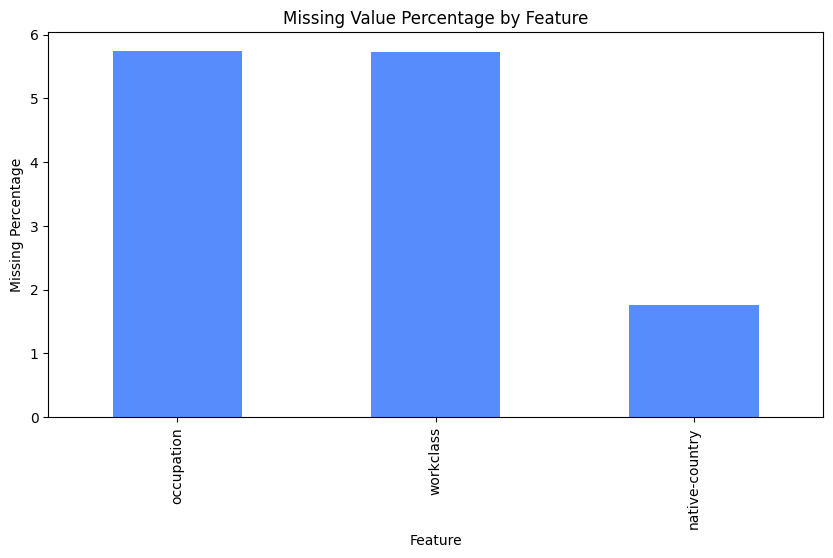

In [57]:
# ============================================================
# Calculate missing-value percentages
# ============================================================

missing_percentages = (
    raw_df.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_percentages)

# ============================================================
# Visualize missing-value percentages
# ============================================================

missing_percentages[
    missing_percentages > 0
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Missing Value Percentage by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage")

plt.show()

The missing-value percentages confirm that missing data is concentrated in only three categorical variables: `occupation`, `workclass`, and `native-country`.

The variables `occupation` and `workclass` contain approximately 5.7% missing values each, while `native-country` contains approximately 1.75% missing values. All remaining variables contain no missing observations.

Although the proportion of missing data is relatively small, these variables may still influence model performance because they contain important demographic and employment-related information. Therefore, appropriate preprocessing strategies must be applied before model training.

## Duplicate Values

Duplicate observations can negatively affect machine learning models by introducing redundant information and potentially biasing the learning process. They may also distort statistical analysis and model evaluation results.

Therefore, the dataset is checked for duplicate rows before preprocessing and model training to ensure data quality and reliability.

In [58]:
# ============================================================
# Identify duplicate rows
# ============================================================

duplicate_count = raw_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 52


The dataset contains 52 duplicate rows.

Although this represents a relatively small proportion of the dataset, duplicate observations may introduce redundant information and bias the learning process. Therefore, these duplicate rows will be removed during preprocessing to improve data quality and ensure more reliable model training and evaluation.

## Target Variable

The distribution of the target variable is analyzed to understand the balance between the two income classes.

In [59]:
# ============================================================
# Analyze target-class distribution
# ============================================================

income_counts = raw_df["income"].value_counts()

income_counts

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

The target-variable distribution confirms that the dataset is moderately imbalanced.

Approximately 37,155 individuals belong to the `<=50K` income class, while only 11,687 individuals belong to the `>50K` class. This indicates that the majority class significantly outnumbers the minority class.

This imbalance is important because machine learning models may become biased toward predicting the majority class, potentially leading to misleading accuracy scores and weaker performance on the minority class. Therefore, additional evaluation metrics such as Precision, Recall, F1-score, MCC, and ROC-AUC will be considered during model evaluation.

In addition, imbalance-handling techniques such as SMOTE and class weighting will later be explored to improve minority-class prediction performance.

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


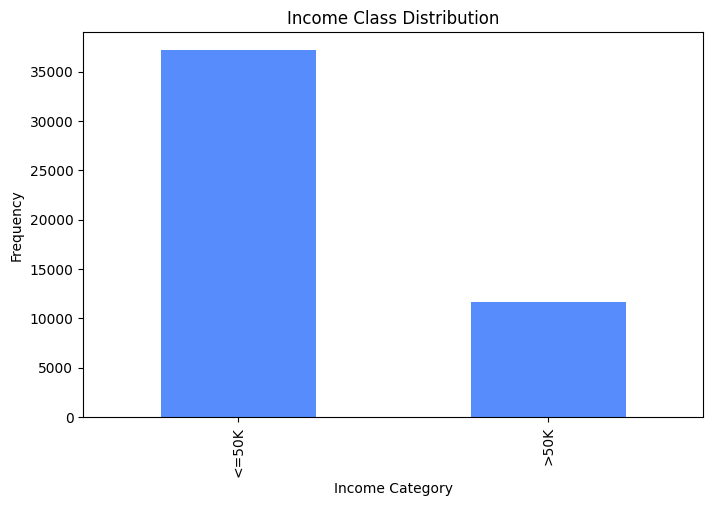

In [60]:
# ============================================================
# Calculate target-class percentages
# ============================================================

income_percentages = (
    raw_df["income"]
    .value_counts(normalize=True) * 100
)

print(income_percentages)

# ============================================================
# Visualize target-class distribution
# ============================================================

plt.figure(figsize=(8, 5))

raw_df["income"].value_counts().plot(
    kind="bar"
)

plt.title("Income Class Distribution")
plt.xlabel("Income Category")
plt.ylabel("Frequency")

plt.show()

The class percentages show that approximately 76% of individuals belong to the `<=50K` income class, while approximately 24% belong to the `>50K` class.

Although the imbalance is not extreme, the dataset is still sufficiently skewed to potentially affect classification performance. Machine learning models trained on imbalanced data may favor the majority class, resulting in reduced sensitivity to minority-class observations.

Therefore, imbalance-handling techniques and multiple evaluation metrics will be considered to ensure a more reliable assessment of model performance.

## Numerical Features

Numerical features are analyzed to understand their distributions, ranges, central tendencies, and potential outliers.

This step is important because skewed distributions, extreme values, and differences in feature scales may influence preprocessing decisions and affect machine learning model performance.

['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


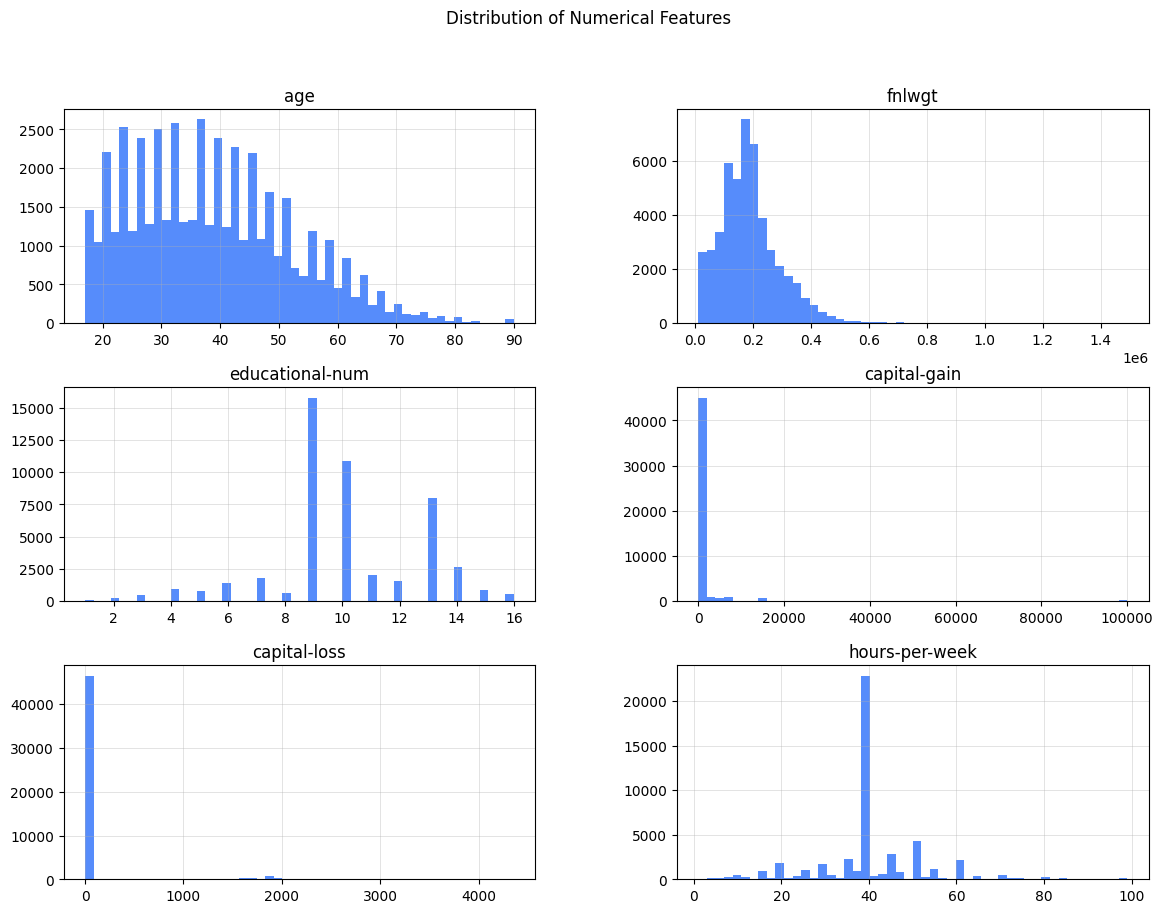

In [61]:
# ============================================================
# Identify numerical features
# ============================================================

numerical_features = raw_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numerical_features)

# ============================================================
# Visualize distributions of numerical features
# ============================================================

raw_df[numerical_features].hist(
    figsize=(14, 10),
    bins=50
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

The histograms reveal important distributional characteristics of the numerical variables in the dataset.

The variable `age` appears moderately right-skewed, with most individuals concentrated between approximately 20 and 50 years old. The variable `hours-per-week` is strongly concentrated around 40 hours, suggesting that many individuals work standard full-time schedules.

Several variables exhibit highly skewed distributions and extreme outliers. In particular, `capital-gain` and `capital-loss` contain a very large concentration of zero values, while a small number of observations contain extremely high values. Similarly, `fnlwgt` displays substantial positive skewness and a wide value range.

These observations are important because highly skewed distributions and extreme values may influence model behavior and preprocessing decisions. In addition, the large differences in feature scales suggest that scaling may benefit certain machine learning algorithms such as Logistic Regression.

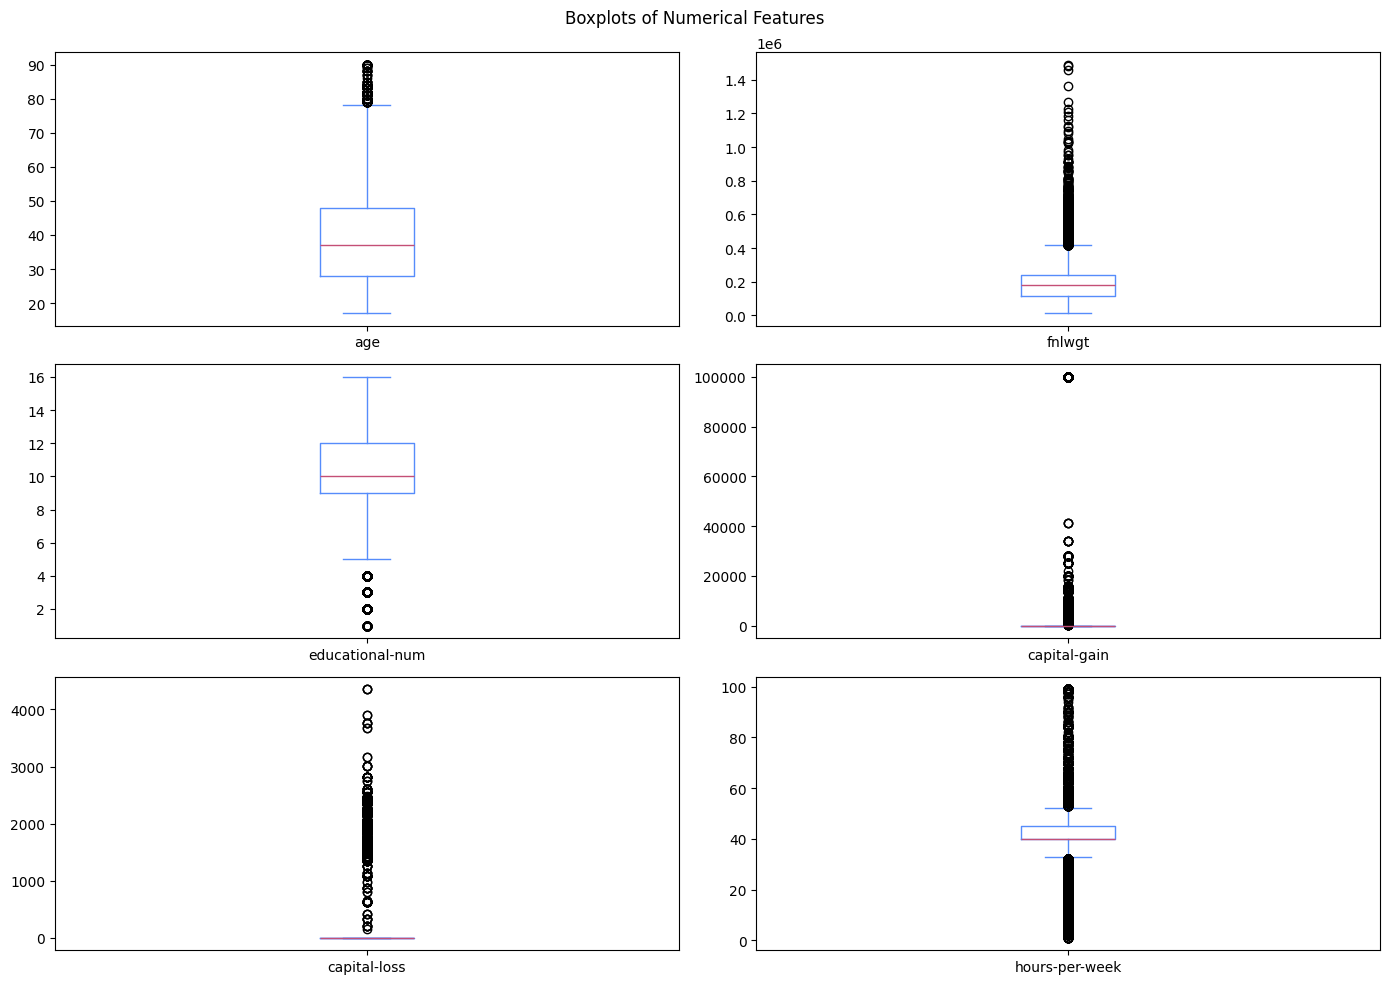

In [62]:
# ============================================================
# Visualize outliers in numerical features
# ============================================================

raw_df[numerical_features].plot(
    kind="box",
    subplots=True,
    layout=(3, 2),
    figsize=(14, 10),
    sharey=False
)

plt.suptitle("Boxplots of Numerical Features")

plt.tight_layout()

plt.show()

The boxplots confirm the presence of skewed distributions and multiple extreme values within several numerical variables.

The variables `capital-gain`, `capital-loss`, and `fnlwgt` contain substantial upper outliers and long right tails, indicating highly non-normal distributions. In contrast, variables such as `age` and `hours-per-week` are more concentrated around their median values, although they still contain some extreme observations.

The variable `hours-per-week` is strongly centered around approximately 40 hours, while `educational-num` appears relatively compact with fewer extreme values compared to the other numerical features.

These observations are important because outliers and skewed distributions may influence certain machine learning algorithms and preprocessing decisions. However, many of these extreme values likely represent legitimate socioeconomic observations rather than data-entry errors. Therefore, the outliers will be retained during modeling, particularly because tree-based algorithms such as Decision Trees and Random Forests are generally robust to extreme values.

## Categorical Features

Categorical features are analyzed to understand the distribution of categories, identify dominant groups, and explore potential relationships with the target variable.

This analysis is important because categorical variables may contain imbalanced category distributions, high-cardinality features, and sensitive demographic information that can influence preprocessing decisions, feature encoding, and machine learning model behavior.

In [63]:
# ============================================================
# Identify categorical features
# ============================================================

categorical_features = raw_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

categorical_features

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'native-country',
 'income']

The dataset contains multiple categorical variables describing demographic, educational, occupational, and socioeconomic characteristics.

Several variables, such as `workclass`, `occupation`, and `native-country`, contain multiple category groups and may require careful preprocessing due to category imbalance and high cardinality. In addition, sensitive demographic variables such as `race` and `gender` are present, which may introduce fairness and bias considerations during model evaluation.

Because machine learning algorithms generally require numerical input, these categorical variables will later be transformed using appropriate encoding techniques during preprocessing.

In [64]:
selected_categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "gender",
    "race",
]

Due to the large number of categorical variables and category groups in the dataset, only the most relevant and interpretable features were selected for detailed visualization.

Features with high category cardinality, such as `native-country`, were analyzed separately to improve readability and avoid overcrowded visualizations. The selected features were chosen based on their potential relationship with income level and their interpretability within a socioeconomic context.

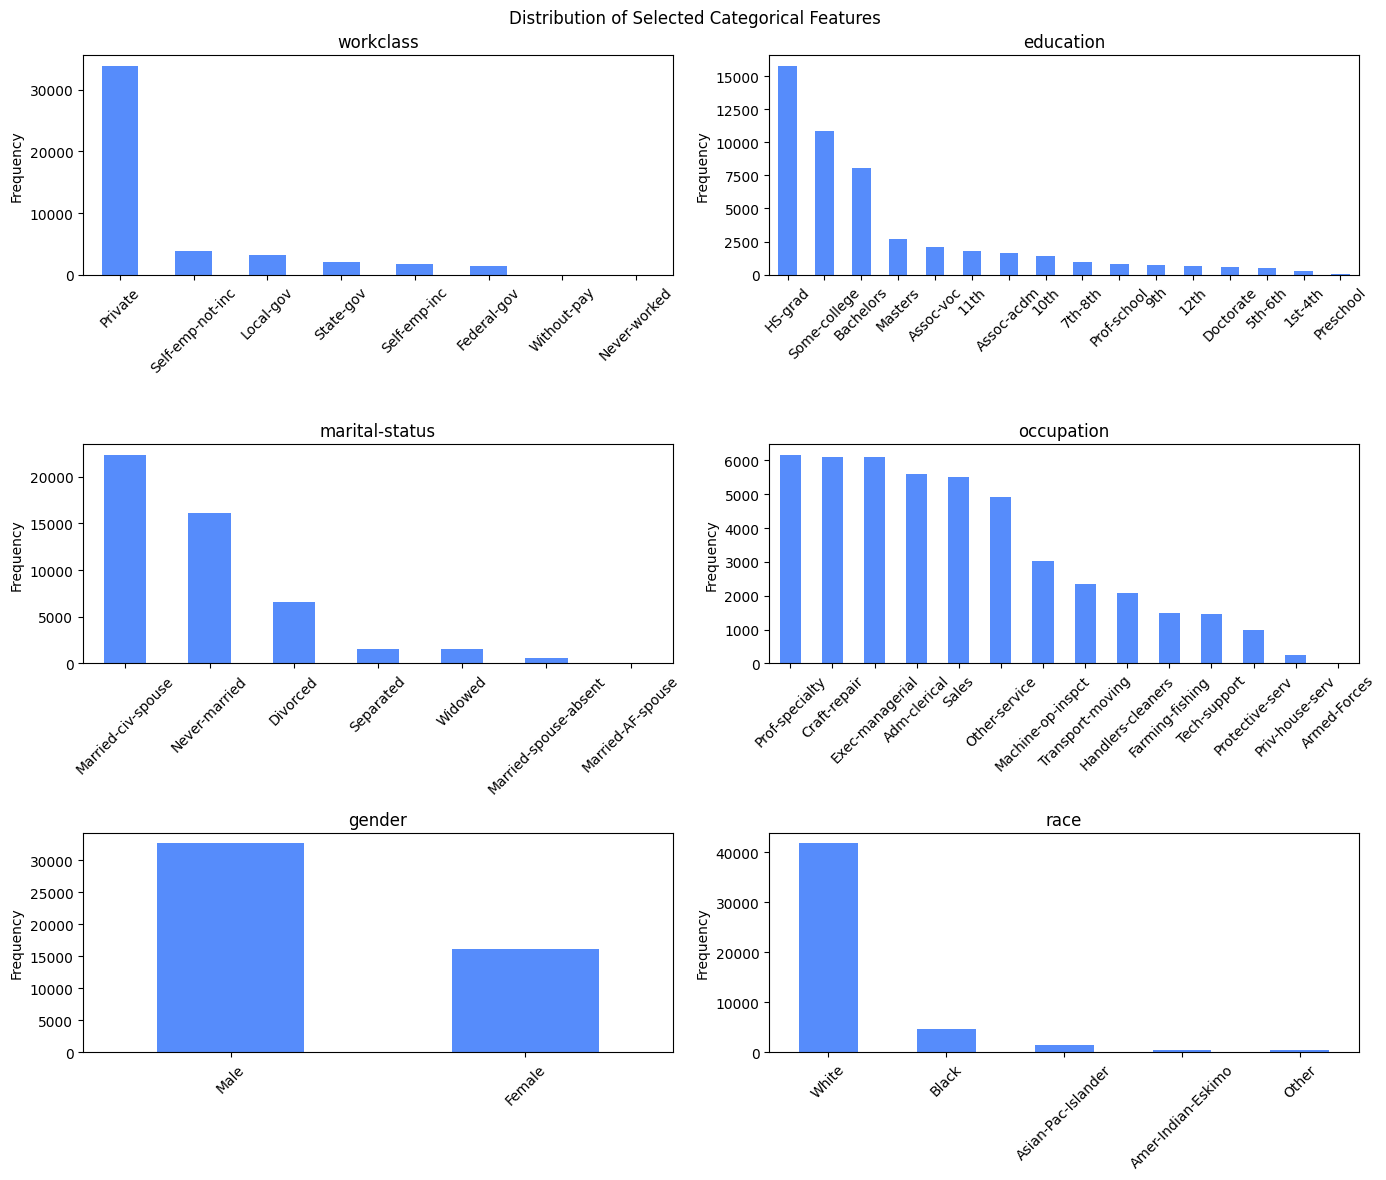

In [65]:
# ============================================================
# Visualize categorical feature distributions
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

axes = axes.flatten()

for ax, feature in zip(axes, selected_categorical_features):

    raw_df[feature].value_counts().plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"{feature}")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Distribution of Selected Categorical Features")

plt.tight_layout()

plt.show()

The categorical feature distributions reveal several important demographic and socioeconomic patterns within the dataset.

The `Private` category dominates the `workclass` feature, while `HS-grad` and `Some-college` represent the most common education levels. The `marital-status` distribution shows that `Married-civ-spouse` and `Never-married` are the largest groups in the dataset.

The `occupation` feature contains multiple category groups with uneven frequencies, suggesting varying representation across employment sectors. In addition, the demographic variables `gender` and `race` are noticeably imbalanced, with male individuals and the `White` category representing the majority of observations.

These patterns are important because categorical imbalance and demographic representation may influence machine learning model behavior, feature encoding, and fairness-related outcomes during model evaluation.

## Relationship Between Categorical Features and Income

To better understand the relationship between socioeconomic characteristics and income level, categorical features are analyzed against the target variable.

This analysis helps identify category groups that may be strongly associated with income differences and provides insight into potentially important predictive patterns for machine learning models.

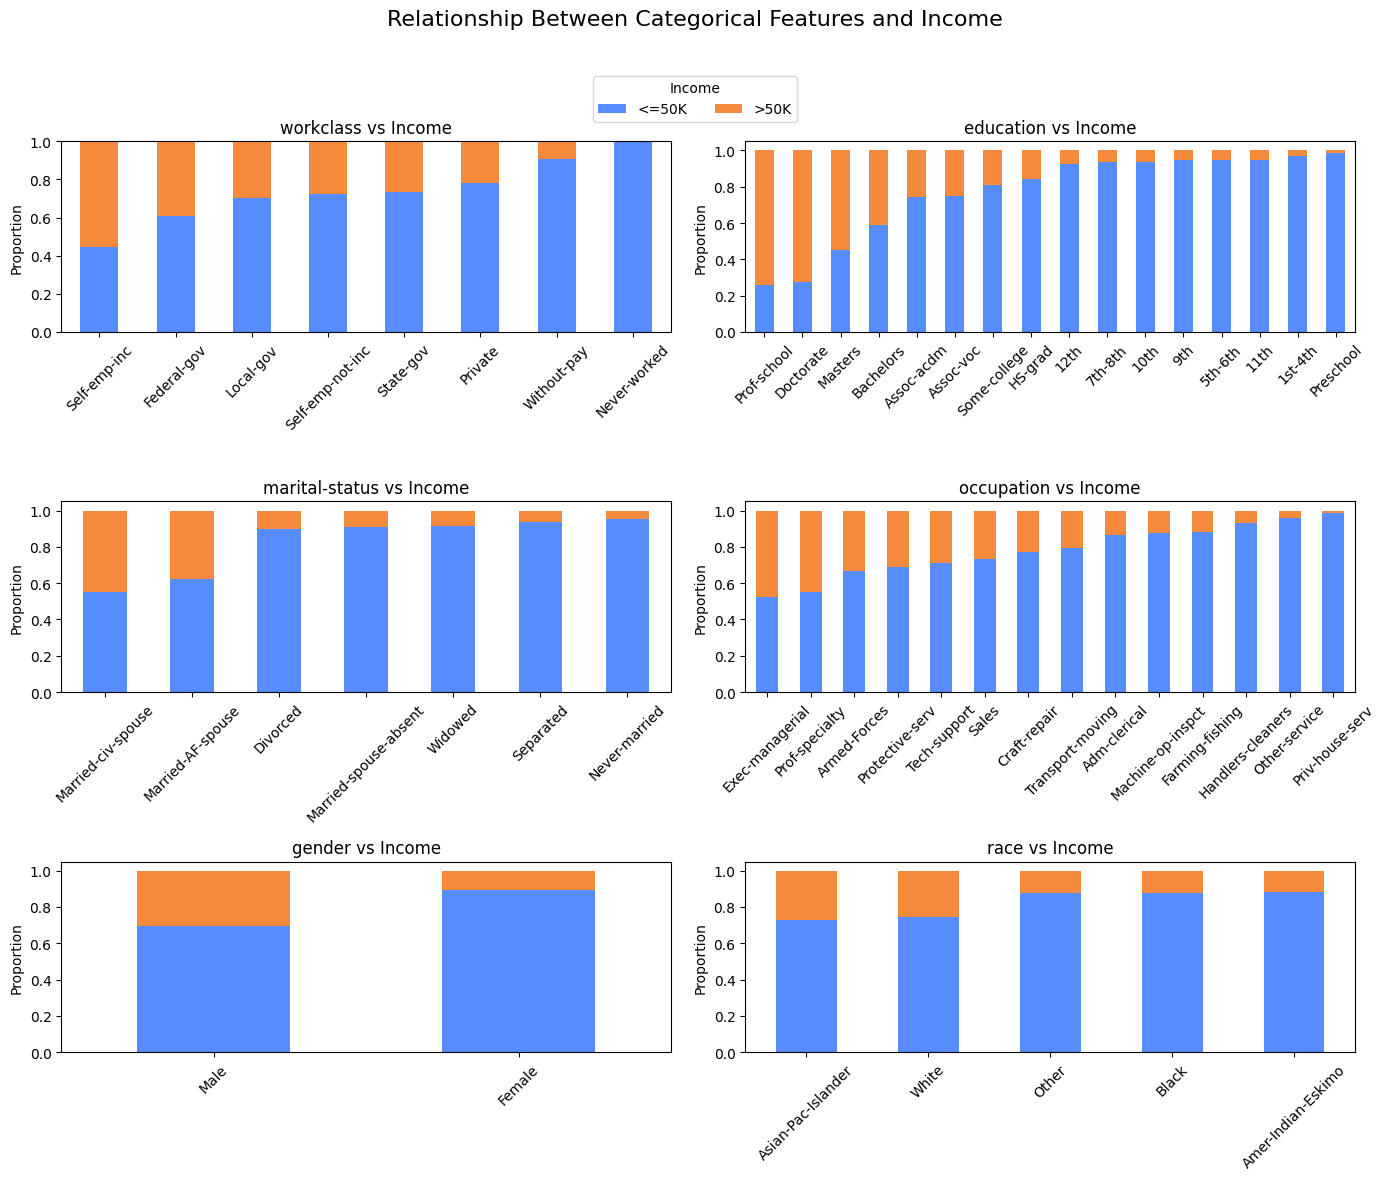

In [66]:
# ============================================================
# Analyze categorical features against income
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

axes = axes.flatten()

for ax, feature in zip(axes, selected_categorical_features):

    pd.crosstab(
        raw_df[feature],
        raw_df["income"],
        normalize="index"
    ).sort_values(
        by=">50K",
        ascending=False
    ).plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False
    )

    ax.set_title(f"{feature} vs Income")
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")

    ax.tick_params(axis="x", rotation=45)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Income",
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.93)
)

plt.suptitle(
    "Relationship Between Categorical Features and Income",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

The relationship between categorical features and income reveals several strong socioeconomic patterns within the dataset.

Education level appears strongly associated with income. Categories such as `Doctorate`, `Prof-school`, `Masters`, and `Bachelors` show substantially larger proportions of individuals earning `>50K`, while lower education categories are dominated by the `<=50K` income group.

Marital status also demonstrates a clear relationship with income. The `Married-civ-spouse` category contains a noticeably larger proportion of higher-income individuals compared with categories such as `Never-married`, `Separated`, and `Widowed`.

Occupation-related differences are also visible. Professional and managerial occupations tend to contain higher proportions of individuals earning `>50K`, whereas service-related and manual occupations are more strongly associated with the lower-income category.

The analysis additionally reveals demographic disparities across `gender` and `race`. Male individuals show a larger proportion of higher-income observations compared with female individuals, while some racial groups also display differing income distributions. These patterns highlight the importance of considering fairness and potential demographic bias during model evaluation and interpretation.

Overall, the observed relationships suggest that categorical variables contain meaningful predictive information for income classification.

## Relationship Between Numerical Features and Income

To better understand the relationship between numerical variables and income level, correlation analysis was performed between the numerical features and the encoded income target.

This analysis helps identify numerical variables that may contain useful predictive information for income classification and provides insight into the strength and direction of linear relationships within the dataset.

The correlation matrix also helps identify highly related numerical features, which is useful for exploratory data analysis and feature interpretation before machine learning model training.

In [67]:
# ============================================================
# Correlation analysis with encoded income target
# ============================================================

correlation_df = raw_df.copy()

correlation_df["income_encoded"] = (
    correlation_df["income"]
    .map({
        "<=50K": 0,
        ">50K": 1,
    })
)

numeric_columns = correlation_df.select_dtypes(
    include=["int64", "float64"]
).columns

correlation_matrix = (
    correlation_df[numeric_columns]
    .corr()
)

correlation_matrix

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income_encoded
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558,0.230369
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519,-0.006339
educational-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689,0.332613
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157,0.223013
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467,0.147554
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000,0.227687
income_encoded,0.230369,-0.006339,0.332613,0.223013,0.147554,0.227687,1.000000


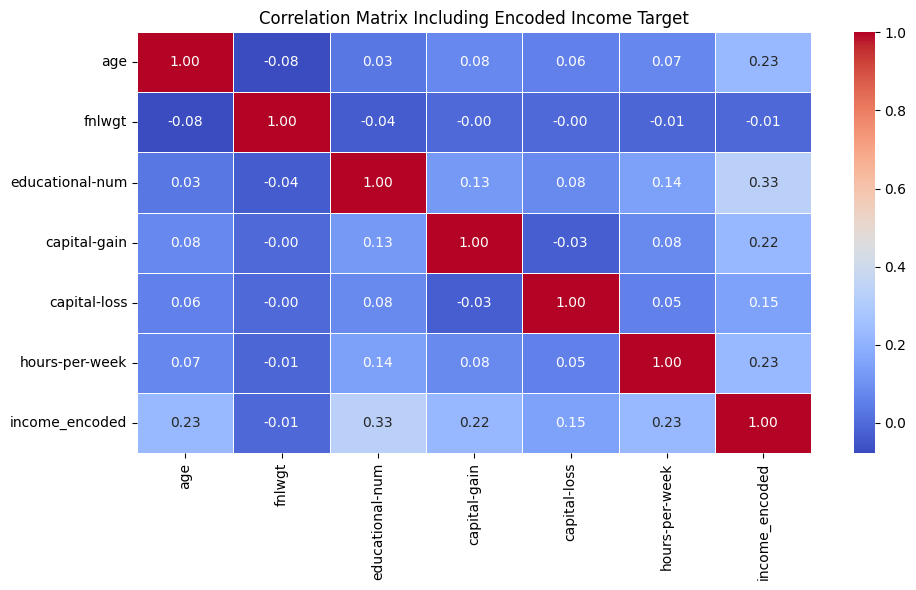

In [68]:
# ============================================================
# Visualize correlation matrix
# ============================================================

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix Including Encoded Income Target")

plt.tight_layout()

plt.show()

The correlation matrix provides an overview of the linear relationships between the numerical variables and the encoded income target.

Among the analyzed variables, `educational-num` showed the strongest positive correlation with income (`0.33`), suggesting that higher education levels are associated with a greater likelihood of belonging to the high-income class (`>50K`). Other variables such as `age` (`0.23`), `hours-per-week` (`0.23`), and `capital-gain` (`0.22`) also demonstrated moderate positive relationships with income.

The variable `capital-loss` showed a weaker positive relationship (`0.15`), while `fnlwgt` exhibited almost no correlation with income (`-0.01`). This suggests that `fnlwgt` may contribute limited meaningful socioeconomic information for income prediction and supports its removal during feature selection and interpretability analysis.

The matrix also shows relatively weak correlations among most numerical variables, indicating limited multicollinearity within the dataset.

Although correlation analysis only captures linear relationships and does not imply causation, it provides useful exploratory insight into the numerical variables that may influence income classification before model training.

### Data Cleaning

After analyzing missing values and duplicated rows, the dataset will be cleaned using the reusable `clean_dataset()` function.

The cleaning process included:
- handling missing values represented by question mark placeholders;
- removing duplicated observations;
- standardizing categorical values where necessary;
- preparing the dataset for preprocessing and machine learning modeling.

In [69]:
clean_df = clean_dataset(raw_df)
clean_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


The cleaning process focused on correcting data-quality issues identified during the exploratory analysis.

Several categorical features contained extra whitespace and missing-value placeholders represented by question marks (`?`). These placeholders were converted into proper missing values (`NaN`) to ensure compatibility with preprocessing and imputation methods. Duplicate observations identified during the analysis were also removed to reduce redundancy in the dataset.

Outliers observed in variables such as `capital-gain`, `capital-loss`, and `hours-per-week` were not removed because they may represent valid socioeconomic patterns rather than data-entry errors. Similarly, missing values were not dropped during cleaning and were instead handled later within the preprocessing pipeline to avoid unnecessary data loss and potential data leakage.

## Feature Engineering and Preprocessing Preparation

Before model training, the dataset is prepared for machine learning by separating the input features from the target variable, identifying numerical and categorical columns, performing feature-engineering transformations, and constructing a reusable preprocessing pipeline.

Several feature-engineering steps were applied to improve data quality, reduce sparsity, and help the models capture more meaningful socioeconomic patterns:

- high-cardinality categorical variables such as `native-country` were grouped into broader categories to reduce sparsity and improve generalization;
- education categories were grouped into broader educational levels to improve interpretability and reduce fragmentation between similar categories;
- binary indicators for `capital-gain` and `capital-loss` were created to capture the presence of investment-related income activity;
- logarithmic transformations (`log1p`) were applied to heavily skewed numerical variables such as `capital-gain` and `capital-loss` to reduce the influence of extreme values.

The preprocessing pipeline applies different transformations to numerical and categorical variables:

- **Numerical features**
  - median imputation for missing values
  - standard scaling to normalize feature magnitudes

- **Categorical features**
  - most-frequent imputation for missing values
  - one-hot encoding for machine learning compatibility

This preprocessing design improves reproducibility and ensures consistent data transformations across the machine learning workflow.

In addition, all preprocessing and feature transformations are fitted only on the training data within the Scikit-learn pipeline. This helps prevent data leakage and supports reliable and fair model evaluation.

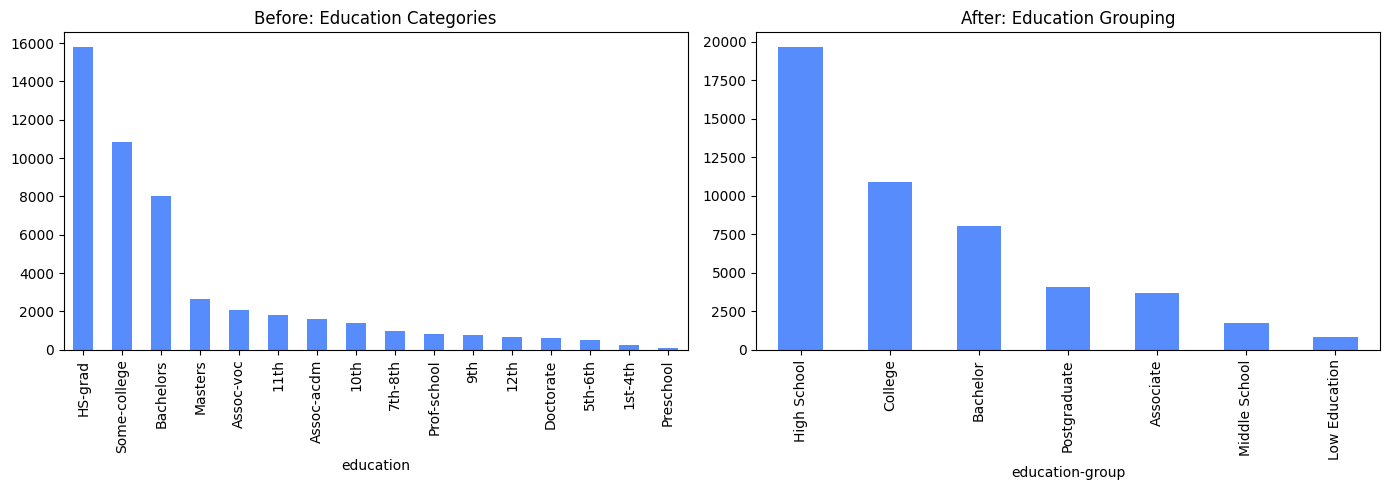

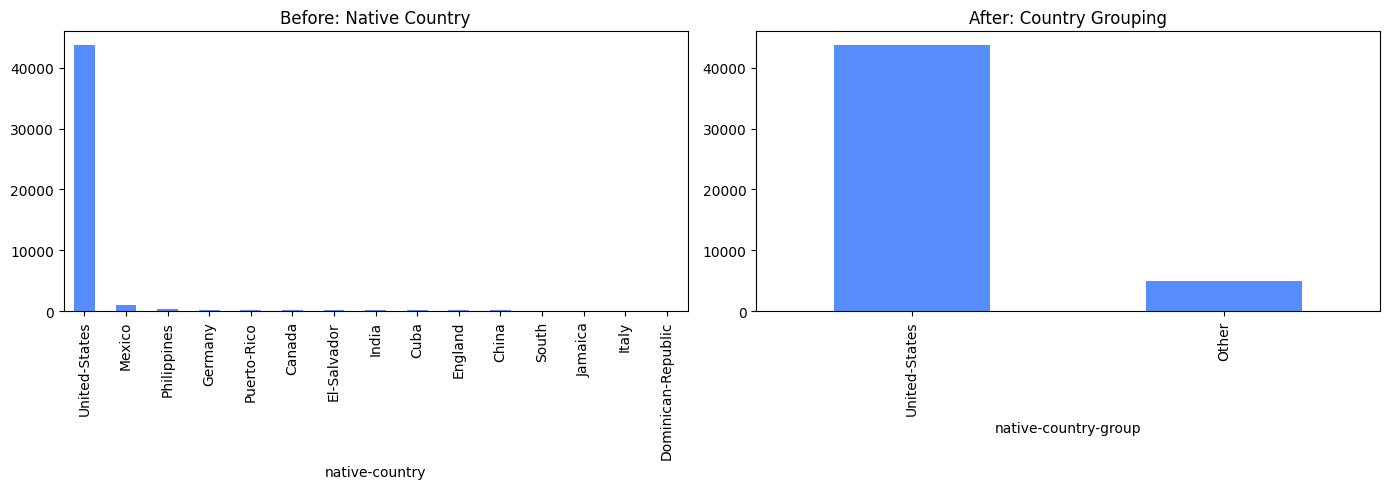

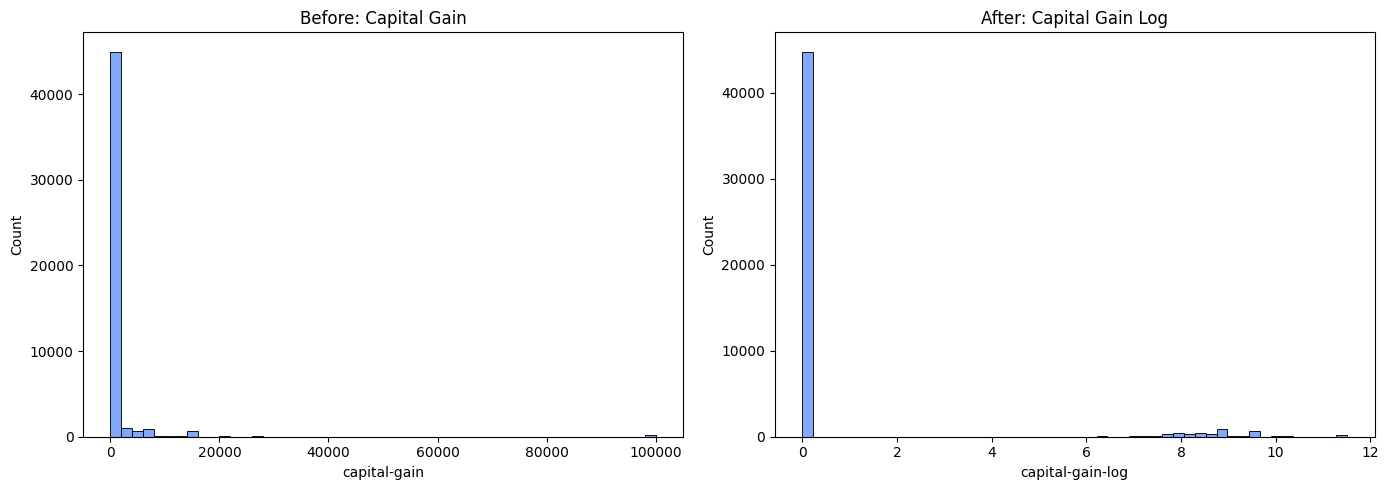

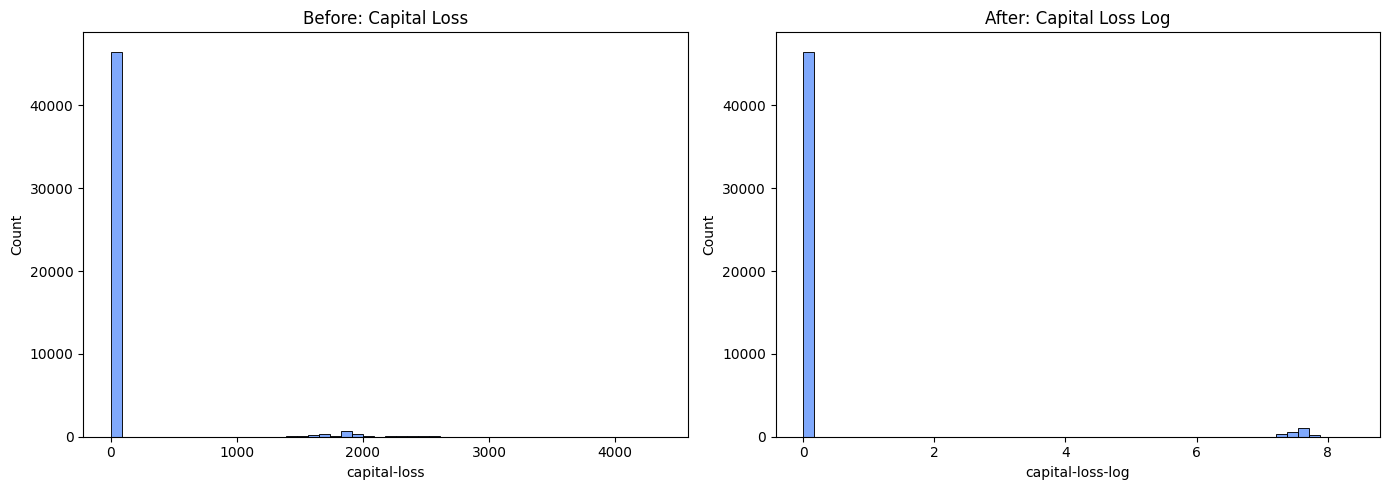

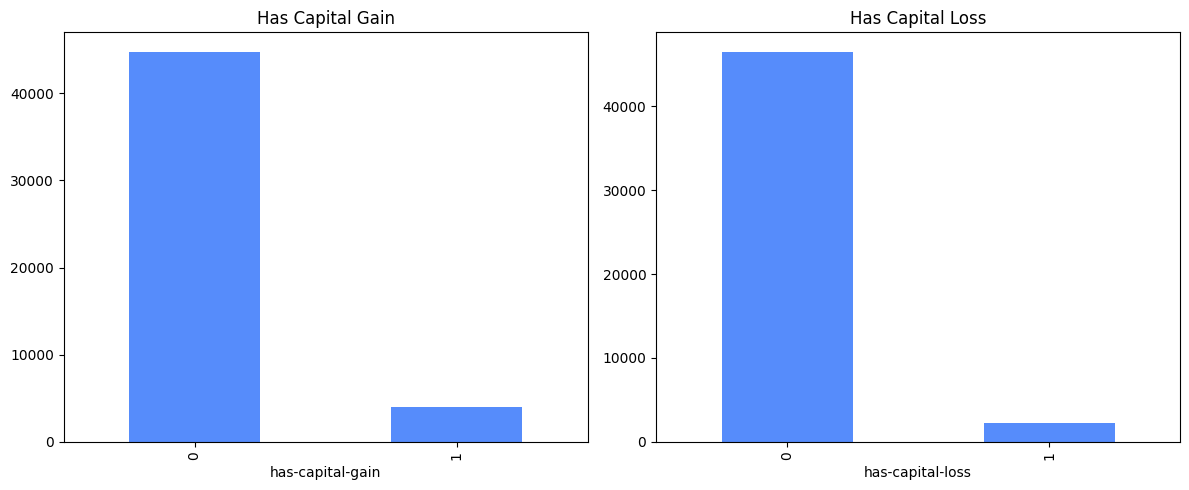

Number of numerical features: 9
Number of categorical features: 10


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,native-country-group,education-group,has-capital-gain,has-capital-loss,capital-gain-log,capital-loss-log
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,United-States,High School,0,0,0.000000,0.0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,United-States,High School,0,0,0.000000,0.0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,United-States,Associate,0,0,0.000000,0.0
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,United-States,College,1,0,8.947546,0.0
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,United-States,College,0,0,0.000000,0.0


In [70]:
# ============================================================
# Prepare features and preprocessing pipeline
# ============================================================
# Apply feature engineering before separating features and target
engineered_df = engineer_features(clean_df)
clean_df = engineer_features(clean_df)

plot_feature_engineering_transformations(
    clean_df=clean_df,
    engineered_df=engineered_df,
)

# Separate input features and target variable
X, y = split_features_target(
    clean_df,
    target_column=TARGET_COLUMN
)

# Identify numerical and categorical features
numerical_features, categorical_features = get_feature_types(X)

# Build preprocessing pipeline
preprocessor = build_preprocessor(
    numerical_features=numerical_features,
    categorical_features=categorical_features,
)

print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")
clean_df.head()

The dataset was successfully separated into input features (`X`) and the target variable (`y`) for machine learning preparation.

The feature-type analysis identified:
- 10 numerical features
- 10 categorical features

This confirms that the dataset contains a mixture of numerical and categorical information, requiring different preprocessing strategies before model training.

Several feature-engineering techniques were also applied before preprocessing to improve model performance and interpretability. In addition, high-cardinality categorical variables such as `native-country` were grouped into broader categories, and education levels were consolidated into more interpretable educational groups.

Additional engineered financial features were created from the highly skewed `capital-gain` and `capital-loss` variables. Binary indicators (`has-capital-gain` and `has-capital-loss`) were introduced to capture the presence of investment-related financial activity, while logarithmic transformations (`capital-gain-log` and `capital-loss-log`) were applied to reduce skewness and improve learning stability.

A reusable preprocessing pipeline was then constructed to ensure consistent handling of missing values, feature scaling, and categorical encoding throughout the machine learning workflow. Numerical variables are processed using median imputation and standard scaling, while categorical variables are processed using most-frequent imputation and one-hot encoding.

The preprocessing steps are applied within a Scikit-learn pipeline to improve reproducibility and prevent data leakage by ensuring that transformations are fitted only on the training data.

The preprocessing and one-hot encoding transformations increased the dataset dimensionality from the original feature space to **117 transformed features**.

This dimensionality expansion occurred because categorical variables were converted into multiple binary indicator variables through one-hot encoding. Each unique category value was transformed into a separate numerical feature, allowing machine learning algorithms to process categorical information effectively.

The final transformed feature matrix contained **48,790 observations** and **117 numerical features**, representing the exact input used during model training.

## Train-Test Split

Before model training, the dataset is divided into training and testing subsets. The training set is used to learn model patterns, while the testing set is reserved for evaluating model performance on unseen data.

This separation is important because evaluating models on previously unseen observations provides a more realistic assessment of generalization performance and helps reduce the risk of overfitting.

In addition, a stratified train-test split is used to preserve the original target-class distribution in both subsets, which is particularly important for imbalanced classification problems.

In [71]:
# ============================================================
# Split dataset into training and testing subsets
# ============================================================

X_train, X_test, y_train, y_test = split_train_test(X, y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (39032, 19)
Testing set shape: (9758, 19)


The dataset was divided into training and testing subsets using an 80/20 split, resulting in:

- 39,032 training observations
- 9,758 testing observations

Stratified sampling was applied to preserve the original income-class distribution in both subsets, which is especially important given the moderate class imbalance identified earlier.

A fixed random state was also used to improve reproducibility and ensure consistent experimental results across multiple executions.

## Transformed Training Feature

In [72]:
# ============================================================
# Apply preprocessing transformations
# ============================================================

# Fit and transform the features
transformed_features = preprocessor.fit_transform(X_train)

# Get transformed feature names
transformed_feature_names = (
    preprocessor.get_feature_names_out()
)

# Convert transformed data into DataFrame
transformed_df = pd.DataFrame(
    transformed_features,
    columns=transformed_feature_names
)

print("Transformed feature shape:")
print(transformed_df.shape)

transformed_df.head()

Transformed feature shape:
(39032, 117)


,age,educational-num,capital-gain,capital-loss,hours-per-week,has-capital-gain,has-capital-loss,capital-gain-log,capital-loss-log,workclass_Federal-gov,...,native-country_Yugoslavia,native-country-group_Other,native-country-group_United-States,education-group_Associate,education-group_Bachelor,education-group_College,education-group_High School,education-group_Low Education,education-group_Middle School,education-group_Postgraduate
0,0.390995,1.139808,-0.144213,-0.219158,0.773301,-0.299349,-0.223438,-0.297158,-0.223305,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-1.214929,1.139808,-0.144213,-0.219158,-1.647323,-0.299349,-0.223438,-0.297158,-0.223305,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.703953,1.139808,-0.144213,-0.219158,0.127801,-0.299349,-0.223438,-0.297158,-0.223305,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-1.214929,-0.419253,-0.144213,-0.219158,0.773301,-0.299349,-0.223438,-0.297158,-0.223305,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.828974,1.529574,-0.144213,-0.219158,0.773301,-0.299349,-0.223438,-0.297158,-0.223305,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


The preprocessing and one-hot encoding transformations increased the dataset dimensionality from the original feature space to 117 transformed features.

This dimensionality expansion occurred because categorical variables were converted into multiple binary indicator variables through one-hot encoding. Each unique category value was transformed into a separate numerical feature, allowing machine learning algorithms to process categorical information effectively.

The preprocessing transformations were fitted only on the training data to prevent data leakage and ensure reliable model evaluation.

The final transformed training feature matrix contained 39,032 observations and 117 numerical features, representing the exact input used during model training.

## Baseline Model

Before training more advanced machine learning models, a baseline classifier is created to establish a reference level of performance.

The baseline model provides a simple benchmark against which more complex models can be compared. This is important because strong evaluation requires demonstrating that trained machine learning models achieve meaningful improvements over naive or majority-class prediction strategies.

Comparing model performance against a baseline also helps assess whether the selected features and preprocessing steps contribute useful predictive information to the classification task.

In [73]:
# ============================================================
# Train and evaluate baseline model
# ============================================================

baseline_pipeline = build_baseline_model(preprocessor)

baseline_pipeline.fit(X_train, y_train)

baseline_predictions = baseline_pipeline.predict(X_test)

baseline_results = evaluate_model(
    model_name="Baseline",
    y_true=y_test,
    y_pred=baseline_predictions,
)

pd.DataFrame([baseline_results.to_dict()])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Baseline,0.760607,0.0,0.0,0.0,0.0,None


The baseline classifier establishes a minimum reference level for model performance.

Because the model always predicts the majority income category (`<=50K`), it achieves an accuracy of approximately 76%. However, this result is misleading because the model does not learn any meaningful patterns from the data.

The baseline completely fails to identify individuals in the minority class (`>50K`), resulting in zero Precision, Recall, F1-score, and MCC. This confirms that accuracy alone is not sufficient for evaluating performance in an imbalanced classification problem.

Therefore, later models will be evaluated using additional metrics such as Precision, Recall, F1-score, ROC-AUC, and Matthews Correlation Coefficient to provide a more balanced assessment of classification performance.

## Class Imbalance Handling

The target variable distribution revealed a moderate class imbalance, with approximately 76% of observations belonging to the `<=50K` class and 24% belonging to the `>50K` class. Although this imbalance is not severe, it can still bias machine learning models toward the majority class and reduce predictive performance for the minority class.

To address this issue, the Synthetic Minority Over-sampling Technique (SMOTE) was applied to the training data. SMOTE generates synthetic minority-class samples by interpolating between existing minority observations rather than simply duplicating them. This helps create a more balanced training distribution while preserving all majority-class samples.

SMOTE was applied only to the training data after the train-test split to prevent data leakage. The testing set was intentionally kept unchanged so that model evaluation reflects realistic class distributions and real-world predictive performance.

In [74]:
# ============================================================
# Compare Logistic Regression performance with and without SMOTE
# ============================================================

numerical_features, categorical_features = get_feature_types(
    X_train
)

preprocessor = build_preprocessor(
    numerical_features=numerical_features,
    categorical_features=categorical_features,
)

imbalance_results, smote_results = compare_smote_effect(
    classifier=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
    ),
    model_name="Logistic Regression",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

smote_comparison_df = pd.DataFrame([
    imbalance_results.to_dict(),
    smote_results.to_dict(),
])

smote_comparison_df.sort_values(
    by="F1 Score",
    ascending=False,
)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
1,Logistic Regression (With SMOTE),0.807338,0.564699,0.851884,0.679181,0.573179,0.905397
0,Logistic Regression (No SMOTE),0.853659,0.742521,0.595034,0.660646,0.574470,0.905478


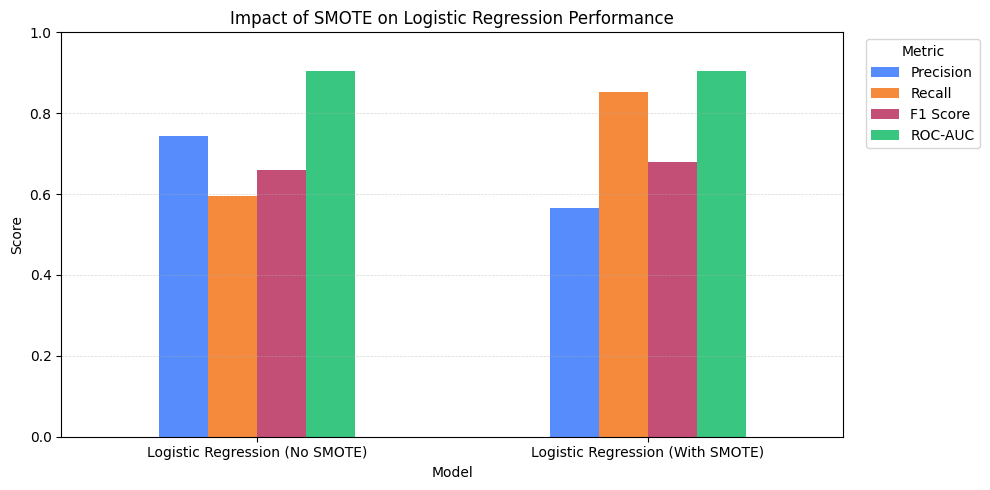

In [75]:
# ============================================================
# Visualize the impact of SMOTE on model performance
# ============================================================

smote_metrics = [
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
]

ax = smote_comparison_df.set_index("Model")[
    smote_metrics
].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title(
    "Impact of SMOTE on Logistic Regression Performance"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.ylim(0, 1)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()

plt.show()

The comparison demonstrates the trade-off introduced by SMOTE.

Applying SMOTE substantially improved Recall for the minority class (`>50K`) from approximately 0.59 to 0.85, meaning the model became significantly better at identifying high-income individuals. The F1-score also increased from approximately 0.66 to 0.68, indicating a better balance between Precision and Recall.

However, this improvement came at the cost of lower Precision and slightly reduced overall Accuracy, meaning the model produced more false-positive predictions for the minority class. ROC-AUC remained almost unchanged, suggesting that the overall ranking ability of the classifier was already strong before oversampling.

Although SMOTE improved minority-class detection, the subsequent models in this project were trained using the original stratified dataset without SMOTE. This decision was made to preserve the natural class distribution and avoid introducing synthetic observations into the training process while still maintaining strong overall predictive performance.

## Machine Learning Models

Multiple machine learning algorithms were trained and compared to evaluate their effectiveness for the income-classification task.

The selected models include both interpretable and ensemble-based approaches, allowing comparison between simpler linear methods and more complex non-linear learning strategies:

- **Logistic Regression** was selected as a strong and interpretable linear baseline commonly used for binary classification problems. It provides probabilistic predictions and allows easier interpretation of feature influence.

- **Decision Tree** was included because of its interpretability and ability to capture non-linear decision boundaries through hierarchical feature splitting. Decision trees also provide intuitive rule-based explanations of predictions.

- **Random Forest** was selected as an ensemble learning method capable of improving predictive performance and reducing overfitting through the aggregation of multiple decision trees. Its ensemble structure generally improves robustness and generalization performance on tabular datasets.

- **Gradient Boosting** was additionally evaluated as a boosting-based ensemble technique that sequentially improves weak learners by focusing on previous classification errors. This approach often achieves strong predictive performance on structured datasets.

Comparing these models helps evaluate the trade-off between:
- interpretability and predictive power,
- simple and complex learning strategies,
- and individual versus ensemble-based machine learning approaches.

To further improve performance and ensure fair comparison, hyperparameter tuning was performed using GridSearchCV with cross-validation.

In [76]:
# Load candidate machine learning models
models = get_candidate_models()
models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

In [77]:
# ============================================================
# Train and evaluate candidate models
# ============================================================

model_results, trained_models = train_and_evaluate_models(
    models=models,
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

The candidate models were trained and evaluated using the same preprocessing pipeline and the same train-test split.

This ensures that the comparison is fair because each model receives the same input features, preprocessing steps, and evaluation data. The results will be compared using multiple classification metrics rather than accuracy alone, since the target variable is moderately imbalanced.

In [78]:
# ============================================================
# Display model evaluation results
# ============================================================

results_df = pd.DataFrame([
    result.to_dict()
    for result in model_results
])

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False,
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
3,Gradient Boosting,0.861037,0.776524,0.589041,0.669912,0.592940,0.917366
0,Logistic Regression,0.853659,0.742521,0.595034,0.660646,0.574470,0.905478
2,Random Forest,0.845563,0.699952,0.621147,0.658199,0.560566,0.891141
1,Decision Tree,0.817893,0.626872,0.591182,0.608504,0.490346,0.771715


The evaluation results show clear performance differences between the selected machine learning models.

Among all evaluated approaches, **Gradient Boosting** achieved the strongest overall predictive performance. The model obtained the highest Accuracy (`0.861`), Precision (`0.777`), F1-score (`0.670`), MCC (`0.593`), and ROC-AUC (`0.917`) values. These results indicate strong classification capability, effective class separation, and robust overall predictive performance across both income classes.

The high Precision score suggests that Gradient Boosting produced fewer false-positive predictions for the high-income class (`>50K`), while the strong ROC-AUC score demonstrates excellent ranking and discrimination capability across different decision thresholds. Its leading F1-score also indicates the best overall balance between Precision and Recall among the evaluated models.

**Logistic Regression** produced competitive results despite being a simpler linear model. The model achieved a strong ROC-AUC score (`0.905`) and maintained balanced overall performance with an F1-score of `0.661`. These results suggest that meaningful linear relationships exist within the dataset. In addition, Logistic Regression remains highly interpretable, making it valuable as a transparent baseline model for comparison against more complex ensemble-based approaches.

**Random Forest** also demonstrated strong predictive performance, particularly in terms of Recall (`0.621`), indicating improved ability to identify individuals belonging to the high-income class. However, its lower Precision compared to Gradient Boosting reduced its overall F1-score slightly. Nevertheless, the model still achieved strong ROC-AUC (`0.891`) and MCC (`0.561`) values, confirming the effectiveness of ensemble learning for structured socioeconomic datasets.

**Decision Tree** achieved the weakest overall performance among the evaluated models, with the lowest Accuracy (`0.818`), F1-score (`0.609`), MCC (`0.490`), and ROC-AUC (`0.772`) scores. Although decision trees provide strong interpretability and transparent decision rules, they are more susceptible to overfitting and instability compared to ensemble-based approaches.

Overall, the results demonstrate that ensemble learning methods, particularly Gradient Boosting and Random Forest, outperform simpler individual models on this dataset. This suggests that combining multiple weak learners improves the ability to capture complex non-linear relationships between socioeconomic characteristics and income level.

## Hyperparameter Tuning

Hyperparameter tuning was performed to improve model performance by identifying more effective parameter configurations for each machine learning algorithm.

Grid Search with cross-validation (`GridSearchCV`) was used to systematically evaluate multiple hyperparameter combinations while reducing the risk of overfitting. Cross-validation improves the reliability of the evaluation process by repeatedly training and validating models on different subsets of the training data.

The tuning process focused on parameters that strongly influence model complexity and predictive performance:

- **Logistic Regression**
  - regularization strength (`C`)
  - optimization solver (`solver`)

- **Decision Tree**
  - maximum tree depth (`max_depth`)
  - minimum samples required for splitting (`min_samples_split`)
  - minimum samples per leaf (`min_samples_leaf`)
  - split criterion (`criterion`)

- **Random Forest**
  - number of trees (`n_estimators`)
  - maximum tree depth (`max_depth`)
  - minimum samples required for splitting (`min_samples_split`)

- **Gradient Boosting**
  - number of boosting stages (`n_estimators`)
  - learning rate (`learning_rate`)
  - tree depth (`max_depth`)
  - subsampling ratio (`subsample`)

The F1-score was used as the primary optimization metric during tuning because it provides a balanced evaluation of Precision and Recall for the moderately imbalanced income-classification problem.

### Logistic Regression Hyperparameter Tuning


In [79]:
# ============================================================
# Tune Logistic Regression
# ============================================================

logistic_grid_search = tune_logistic_regression(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
)

print("Best Logistic Regression Parameters:")
print(logistic_grid_search.best_params_)

print(
    f"Best Cross-Validated F1 Score: "
    f"{logistic_grid_search.best_score_:.4f}"
)

Best Logistic Regression Parameters:
{'classifier__C': 10, 'classifier__solver': 'liblinear'}
Best Cross-Validated F1 Score: 0.6644


The optimal Logistic Regression configuration used a relatively weak regularization strength (`C = 10`) together with the `liblinear` optimization solver.

A larger `C` value reduces regularization, allowing the model to fit the training data more closely and capture stronger relationships between features and income level. The `liblinear` solver performed best for this binary-classification problem and is particularly effective for smaller and medium-sized structured datasets.

The cross-validated F1-score of **0.6644** indicates that the tuned Logistic Regression model achieved a balanced trade-off between Precision and Recall during training. This represents an improvement over the untuned baseline configuration and demonstrates the value of hyperparameter optimization.

### Decision Tree Hyperparameter Tuning

The Decision Tree classifier was initially trained using default hyperparameters. To ensure a fair and complete comparison across the selected models, hyperparameter tuning was also applied to the Decision Tree using Grid Search with 5-fold cross-validation.

The tuning process focused on parameters that control tree complexity and splitting behavior:

- `max_depth`: limits the maximum depth of the tree and helps reduce overfitting;
- `min_samples_split`: controls the minimum number of samples required to split an internal node;
- `min_samples_leaf`: controls the minimum number of samples required at each leaf node;
- `criterion`: defines the function used to measure split quality.

As with the other models, F1-score was used as the optimization target because it balances Precision and Recall, which is important for the moderately imbalanced income-classification task.

In [80]:
# ============================================================
# Tune Decision Tree
# ============================================================

decision_tree_grid_search = tune_decision_tree(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
)

print("Best Decision Tree Parameters:")
print(decision_tree_grid_search.best_params_)

print(
    f"Best Cross-Validated F1 Score: "
    f"{decision_tree_grid_search.best_score_:.4f}"
)

Best Decision Tree Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20}
Best Cross-Validated F1 Score: 0.6725


The optimal Decision Tree configuration used:
- the `gini` impurity criterion,
- a maximum tree depth of `15`,
- a minimum leaf size of `10`,
- and a minimum split size of `2`.

Limiting the tree depth and increasing the minimum number of samples per leaf helps reduce overfitting by preventing the tree from learning highly specific patterns from the training data. This improves the model’s ability to generalize to unseen observations.

The tuned Decision Tree achieved a cross-validated F1-score of **0.6725**, representing a substantial improvement over the default configuration. The results indicate that controlling tree complexity significantly improves predictive performance while preserving the interpretability advantages of decision-tree models.

### Random Forest Hyperparameter Tuning


In [81]:
# ============================================================
# Tune Random Forest
# ============================================================

random_forest_grid_search = tune_random_forest(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
)

print("Best Random Forest Parameters:")
print(random_forest_grid_search.best_params_)

print(
    f"Best Cross-Validated F1 Score: "
    f"{random_forest_grid_search.best_score_:.4f}"
)

/Users/buharinasirahmad/PycharmProjects/PythonProject/Adult-census-income-ML-project/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/buharinasirahmad/PycharmProjects/PythonProject/Adult-census-income-ML-project/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/buharinasirahmad/PycharmProjects/PythonProject/Adult-census-income-ML-project/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Paral

Best Random Forest Parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best Cross-Validated F1 Score: 0.6795


The optimal Random Forest configuration used:
- a maximum tree depth of 20,
- a minimum split size of 5,
- and 200 decision trees in the ensemble.

Increasing the number of trees improves model stability and reduces variance by averaging predictions across multiple decision trees. Limiting the maximum tree depth and requiring a minimum number of samples for splitting also helps control overfitting while still allowing the model to capture complex non-linear relationships within the dataset.

The tuned Random Forest achieved a cross-validated F1-score of **0.6795**, outperforming the tuned Logistic Regression model. This suggests that the ensemble-based approach is better able to model the complex interactions between demographic and socioeconomic features associated with income level.

### Gradient Boosting Hyperparameter Tuning

In [82]:
# ============================================================
# Tune Gradient Boosting
# ============================================================

gradient_boosting_grid_search = tune_gradient_boosting(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
)

print("Best Gradient Boosting Parameters:")
print(gradient_boosting_grid_search.best_params_)

print(
    f"Best Cross-Validated F1 Score: "
    f"{gradient_boosting_grid_search.best_score_:.4f}"
)

Best Gradient Boosting Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Best Cross-Validated F1 Score: 0.7146


The optimal Gradient Boosting configuration used:
- a learning rate of `0.1`,
- a maximum tree depth of `5`,
- `200` boosting stages,
- and a subsampling ratio of `0.8`.

The cross-validated F1-score of **0.7146** is higher than the tuned Logistic Regression, Decision Tree, and Random Forest models. This suggests that Gradient Boosting provides the strongest balance between Precision and Recall among the tuned models.

The result is expected because Gradient Boosting sequentially improves weak learners by focusing on previous errors, allowing it to capture complex non-linear relationships in the dataset. However, this improved predictive performance comes at the cost of reduced interpretability compared with Logistic Regression and Decision Tree models.

Gradient Boosting obtained the highest cross-validated F1-score, outperforming both Random Forest and the individual interpretable models.

These results suggest that ensemble learning methods are better able to capture the complex non-linear relationships between demographic, educational, and socioeconomic features associated with income level. The findings also demonstrate the advantage of combining multiple weak learners to improve robustness, generalization performance, and minority-class prediction.

## Final Model Evaluation

After hyperparameter tuning, the optimized models are evaluated on the unseen testing dataset to assess their real-world generalization performance.

Multiple evaluation metrics are used to provide a balanced assessment of model quality, particularly because the dataset exhibits moderate class imbalance. Relying only on Accuracy could produce misleading conclusions, especially when evaluating minority-class predictions.

The following evaluation metrics are considered:

- **Accuracy** — overall proportion of correct predictions;
- **Precision** — proportion of predicted positive cases that are actually positive;
- **Recall** — proportion of actual positive cases correctly identified;
- **F1-score** — harmonic mean of Precision and Recall;
- **ROC-AUC** — model ability to distinguish between income classes across decision thresholds;
- **Matthews Correlation Coefficient (MCC)** — balanced metric that considers all confusion-matrix outcomes and is particularly informative for imbalanced classification problems.

The final evaluation compares the tuned models to determine which approach provides the best balance between predictive performance, robustness, and interpretability.

In [83]:
# ============================================================
# Evaluate tuned Logistic Regression on the test set
# ============================================================

best_logistic_model = (
    logistic_grid_search.best_estimator_
)

logistic_predictions = best_logistic_model.predict(
    X_test
)

logistic_probabilities = (
    best_logistic_model.predict_proba(X_test)[:, 1]
)

tuned_logistic_results = evaluate_model(
    model_name="Tuned Logistic Regression",
    y_true=y_test,
    y_pred=logistic_predictions,
    y_prob=logistic_probabilities,
)

pd.DataFrame([
    tuned_logistic_results.to_dict()
])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Logistic Regression,0.853863,0.742021,0.597175,0.661765,0.575415,0.905615


The tuned Logistic Regression model achieved strong overall performance on the testing dataset, obtaining an Accuracy of **0.8539**, Precision of **0.7420**, Recall of **0.5972**, F1-score of **0.6618**, MCC of **0.5754**, and ROC-AUC of **0.9056**.

The high ROC-AUC score indicates that the model is effective at distinguishing between the two income classes across different decision thresholds. The relatively high Precision also suggests that the model produces fewer false-positive predictions for the high-income class (`>50K`).

Compared with the baseline classifier, the tuned Logistic Regression model substantially improved all evaluation metrics, demonstrating that meaningful predictive relationships exist within the dataset.

Although Logistic Regression is a relatively simple linear model, it provides competitive predictive performance while remaining highly interpretable. This makes it valuable both as a predictive model and as a transparent benchmark for comparison against more complex ensemble-based approaches.

In [84]:
# ============================================================
# Evaluate tuned Decision Tree on the test set
# ============================================================

best_decision_tree_model = (
    decision_tree_grid_search.best_estimator_
)

decision_tree_predictions = (
    best_decision_tree_model.predict(X_test)
)

decision_tree_probabilities = (
    best_decision_tree_model.predict_proba(X_test)[:, 1]
)

tuned_decision_tree_results = evaluate_model(
    model_name="Tuned Decision Tree",
    y_true=y_test,
    y_pred=decision_tree_predictions,
    y_prob=decision_tree_probabilities,
)

pd.DataFrame([
    tuned_decision_tree_results.to_dict()
])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Decision Tree,0.855811,0.757626,0.58476,0.660063,0.578185,0.901971


The tuned Decision Tree model achieved strong predictive performance on the testing dataset, obtaining an Accuracy of **0.8558**, Precision of **0.7576**, Recall of **0.5848**, F1-score of **0.6601**, MCC of **0.5782**, and ROC-AUC of **0.9020**.

Compared with the tuned Logistic Regression model, the tuned Decision Tree achieved higher Accuracy, Precision, MCC, and ROC-AUC values, indicating improved overall classification performance and stronger class-separation capability. The higher Precision suggests that the model produced fewer false-positive predictions for the high-income class (`>50K`).

However, the model achieved lower Recall than Logistic Regression, indicating a weaker ability to correctly identify some individuals belonging to the high-income class. This suggests that the Decision Tree adopted a more conservative prediction strategy for the minority class.

Despite these limitations, the Decision Tree remains highly interpretable because the learned decision rules can be visualized and explained directly. This makes it valuable for understanding feature interactions and model decision behavior, even when more complex ensemble-based approaches achieve stronger predictive performance.

In [85]:
# ============================================================
# Evaluate tuned Random Forest on the test set
# ============================================================

best_random_forest_model = (
    random_forest_grid_search.best_estimator_
)

random_forest_predictions = (
    best_random_forest_model.predict(X_test)
)

random_forest_probabilities = (
    best_random_forest_model.predict_proba(X_test)[:, 1]
)

tuned_random_forest_results = evaluate_model(
    model_name="Tuned Random Forest",
    y_true=y_test,
    y_pred=random_forest_predictions,
    y_prob=random_forest_probabilities,
)

pd.DataFrame([
    tuned_random_forest_results.to_dict()
])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Random Forest,0.862369,0.786497,0.583476,0.669943,0.595814,0.915609


The tuned Random Forest model achieved strong predictive performance on the testing dataset, obtaining an Accuracy of **0.8624**, Precision of **0.7865**, Recall of **0.5835**, F1-score of **0.6699**, MCC of **0.5958**, and ROC-AUC of **0.9156**.

Compared with the tuned Logistic Regression and Decision Tree models, Random Forest achieved higher Accuracy, Precision, F1-score, MCC, and ROC-AUC values, indicating improved predictive capability and stronger overall class discrimination performance. The high Precision score suggests that the model produced fewer false-positive predictions for the high-income class (`>50K`), while the strong MCC value indicates balanced classification performance across both income classes.

These results demonstrate the effectiveness of ensemble learning methods for handling complex non-linear relationships within socioeconomic datasets. By aggregating predictions from multiple decision trees, Random Forest improves robustness and generalization performance while reducing the overfitting risk associated with a single Decision Tree model.

Although Random Forest achieved stronger predictive performance than the simpler models, the model is less interpretable than approaches such as Logistic Regression and Decision Trees. This highlights the common trade-off between interpretability and predictive performance in machine learning applications.

In [86]:
# ============================================================
# Evaluate tuned Gradient Boosting on the test set
# ============================================================

best_gradient_boosting_model = (
    gradient_boosting_grid_search.best_estimator_
)

gradient_boosting_predictions = (
    best_gradient_boosting_model.predict(X_test)
)

gradient_boosting_probabilities = (
    best_gradient_boosting_model.predict_proba(X_test)[:, 1]
)

tuned_gradient_boosting_results = evaluate_model(
    model_name="Tuned Gradient Boosting",
    y_true=y_test,
    y_pred=gradient_boosting_predictions,
    y_prob=gradient_boosting_probabilities,
)

pd.DataFrame([
    tuned_gradient_boosting_results.to_dict()
])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Gradient Boosting,0.869235,0.773478,0.641695,0.701451,0.623085,0.925209


The tuned Gradient Boosting model achieved the strongest overall predictive performance on the testing dataset, obtaining an Accuracy of **0.8692**, Precision of **0.7735**, Recall of **0.6417**, F1-score of **0.7015**, MCC of **0.6231**, and ROC-AUC of **0.9252**.

Compared with the other evaluated models, Gradient Boosting achieved the highest Accuracy, Recall, F1-score, MCC, and ROC-AUC values, indicating superior predictive capability, stronger class-separation performance, and more balanced classification across both income classes. The strong Recall value demonstrates improved ability to correctly identify individuals belonging to the high-income class (`>50K`), while the high ROC-AUC score indicates excellent discrimination capability across different classification thresholds.

These results demonstrate the effectiveness of boosting-based ensemble learning for modeling complex non-linear socioeconomic relationships. By sequentially combining multiple weak learners and focusing on previously misclassified observations, Gradient Boosting improves predictive performance and generalization capability beyond individual decision trees and simpler linear models.

Although Gradient Boosting achieved the best overall predictive performance, the model is less interpretable than simpler approaches such as Logistic Regression and Decision Trees. This highlights the common trade-off between predictive accuracy and model interpretability in machine learning applications.

In [87]:
# ============================================================
# Compare final tuned model performances
# ============================================================

final_results_df = pd.DataFrame([
    tuned_logistic_results.to_dict(),
    tuned_decision_tree_results.to_dict(),
    tuned_random_forest_results.to_dict(),
    tuned_gradient_boosting_results.to_dict(),
])

final_results_df = final_results_df.sort_values(
    by="F1 Score",
    ascending=False,
)

final_results_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
3,Tuned Gradient Boosting,0.869235,0.773478,0.641695,0.701451,0.623085,0.925209
2,Tuned Random Forest,0.862369,0.786497,0.583476,0.669943,0.595814,0.915609
0,Tuned Logistic Regression,0.853863,0.742021,0.597175,0.661765,0.575415,0.905615
1,Tuned Decision Tree,0.855811,0.757626,0.584760,0.660063,0.578185,0.901971


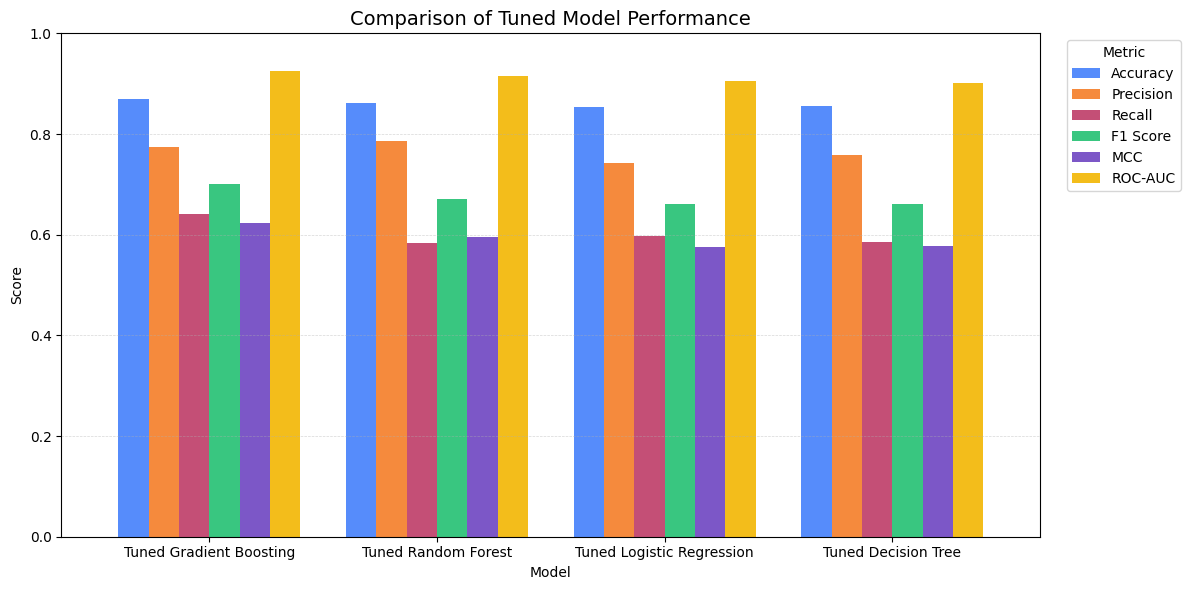

In [88]:
# ============================================================
# Visualize tuned model performance comparison
# ============================================================

comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC",
    "ROC-AUC",
]

ax = final_results_df.set_index("Model")[
    comparison_metrics
].plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
)

plt.title(
    "Comparison of Tuned Model Performance",
    fontsize=14,
)

plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=0)

plt.ylim(0, 1)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5,
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.show()

The final comparison of the tuned machine learning models demonstrates that the ensemble-based approaches achieved the strongest overall predictive performance for the Adult Income classification task.

Among all evaluated models, the tuned Gradient Boosting classifier achieved the best overall results, obtaining the highest Accuracy (**0.8692**), Recall (**0.6417**), F1-score (**0.7015**), MCC (**0.6231**), and ROC-AUC (**0.9252**). These results indicate superior class-separation capability and a stronger balance between minority-class detection and overall predictive performance.

The tuned Random Forest model also performed strongly, achieving an Accuracy of (**0.8624**), Precision (**0.7865**), Recall (**0.5835**), F1-score (**0.6699**), MCC (**0.5958**), and ROC-AUC (**0.9156**). In particular, Random Forest achieved the highest Precision among all evaluated models, suggesting fewer false-positive predictions for the high-income class (`>50K`). These results further demonstrate the effectiveness of ensemble learning methods for capturing complex non-linear relationships within socioeconomic datasets.

The tuned Decision Tree achieved competitive performance, with an Accuracy of (**0.8558**), Precision (**0.7576**), Recall (**0.5848**), F1-score (**0.6601**), MCC (**0.5782**), and ROC-AUC (**0.9020**). In addition to its predictive capability, the Decision Tree maintained full interpretability through explicit decision rules. However, its overall performance remained lower than the ensemble-based approaches, reflecting the limitations of relying on a single tree structure.

Although the tuned Logistic Regression model achieved slightly lower predictive performance, it remained highly competitive while offering substantially greater interpretability and computational simplicity. The model obtained an Accuracy of (**0.8539**), Precision (**0.7420**), Recall (**0.5972**), F1-score (**0.6618**), MCC (**0.5754**), and ROC-AUC (**0.9056**). These results demonstrate that relatively simple linear models can still perform effectively on structured tabular datasets.

Overall, the results show that ensemble learning methods, particularly Gradient Boosting, are better suited for modeling the complex relationships present in the Adult Income dataset. However, the improved predictive performance comes at the cost of reduced interpretability and increased computational complexity, highlighting the common trade-off between transparency and predictive power in machine learning applications.

## ROC Curve Comparison

Receiver Operating Characteristic (ROC) curves are used to evaluate the classification performance of the tuned models across different probability thresholds.

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate. The Area Under the Curve (ROC-AUC) summarizes the model’s overall ability to distinguish between the low-income (`<=50K`) and high-income (`>50K`) classes.

Higher ROC-AUC values indicate stronger class-separation capability and better overall discrimination performance.

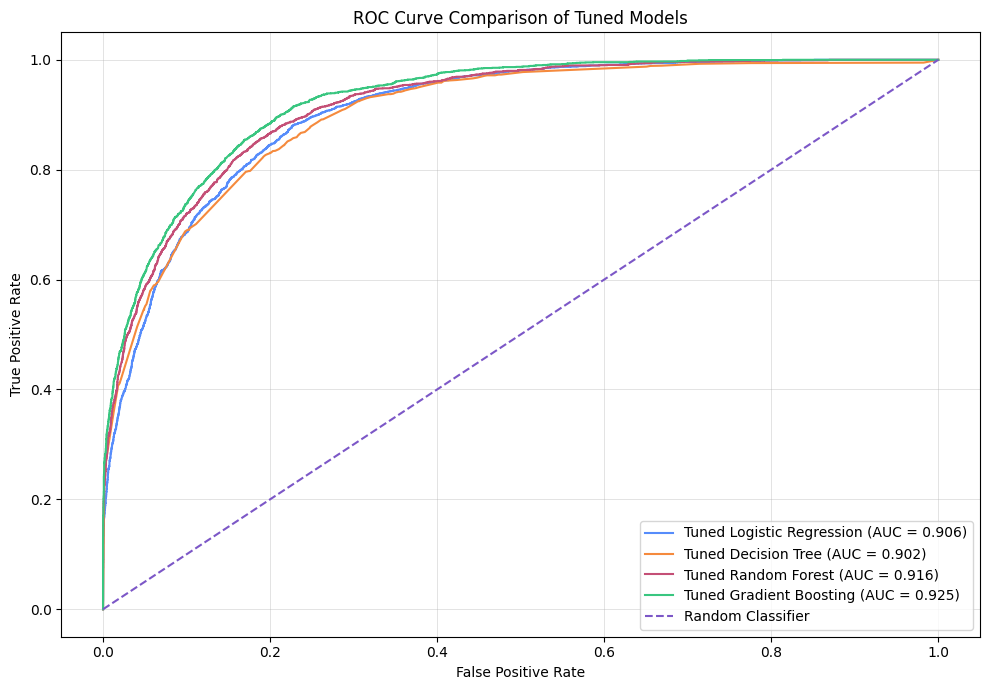

In [89]:
# ============================================================
# ROC curve comparison for tuned models
# ============================================================

from sklearn.metrics import roc_curve, auc


plt.figure(figsize=(10, 7))


# Logistic Regression
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities,
    pos_label=">50K",
)

logistic_auc = auc(
    logistic_fpr,
    logistic_tpr,
)

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=(
        f"Tuned Logistic Regression "
        f"(AUC = {logistic_auc:.3f})"
    ),
)


# Decision Tree
decision_tree_fpr, decision_tree_tpr, _ = roc_curve(
    y_test,
    decision_tree_probabilities,
    pos_label=">50K",
)

decision_tree_auc = auc(
    decision_tree_fpr,
    decision_tree_tpr,
)

plt.plot(
    decision_tree_fpr,
    decision_tree_tpr,
    label=(
        f"Tuned Decision Tree "
        f"(AUC = {decision_tree_auc:.3f})"
    ),
)


# Random Forest
random_forest_fpr, random_forest_tpr, _ = roc_curve(
    y_test,
    random_forest_probabilities,
    pos_label=">50K",
)

random_forest_auc = auc(
    random_forest_fpr,
    random_forest_tpr,
)

plt.plot(
    random_forest_fpr,
    random_forest_tpr,
    label=(
        f"Tuned Random Forest "
        f"(AUC = {random_forest_auc:.3f})"
    ),
)


# Gradient Boosting
gradient_boosting_fpr, gradient_boosting_tpr, _ = roc_curve(
    y_test,
    gradient_boosting_probabilities,
    pos_label=">50K",
)

gradient_boosting_auc = auc(
    gradient_boosting_fpr,
    gradient_boosting_tpr,
)

plt.plot(
    gradient_boosting_fpr,
    gradient_boosting_tpr,
    label=(
        f"Tuned Gradient Boosting "
        f"(AUC = {gradient_boosting_auc:.3f})"
    ),
)


# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)


plt.title(
    "ROC Curve Comparison of Tuned Models"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

plt.show()

The ROC curve comparison demonstrates that all tuned machine learning models substantially outperformed the random-classification baseline, confirming that the models successfully learned meaningful predictive patterns from the dataset.

Among the evaluated models, the tuned Gradient Boosting classifier achieved the strongest ROC-AUC performance, indicating superior ability to distinguish between the low-income and high-income classes across different classification thresholds. The tuned Random Forest model also demonstrated strong discrimination capability, followed by Logistic Regression and Decision Tree.

The relatively high ROC-AUC values across all models suggest that the selected features and preprocessing pipeline captured important socioeconomic relationships related to income classification.

The ROC analysis also reinforces the earlier evaluation results, where ensemble-based methods consistently achieved stronger overall predictive performance than the simpler linear and single-tree models.

## Confusion Matrix Analysis

Confusion matrices are used to analyze the specific types of classification errors made by the machine learning models. Unlike aggregate metrics such as Accuracy or F1-score, confusion matrices provide a more detailed view of how predictions are distributed across the actual and predicted classes.

For binary income classification, the confusion matrix consists of four components:

- **True Positives (TP)** — high-income individuals correctly classified as `>50K`;
- **True Negatives (TN)** — low-income individuals correctly classified as `<=50K`;
- **False Positives (FP)** — low-income individuals incorrectly classified as `>50K`;
- **False Negatives (FN)** — high-income individuals incorrectly classified as `<=50K`.

Analyzing these outcomes helps identify whether a model is biased toward one class and provides additional insight into the trade-off between Precision and Recall. This is particularly important for moderately imbalanced datasets such as the Adult Income dataset.

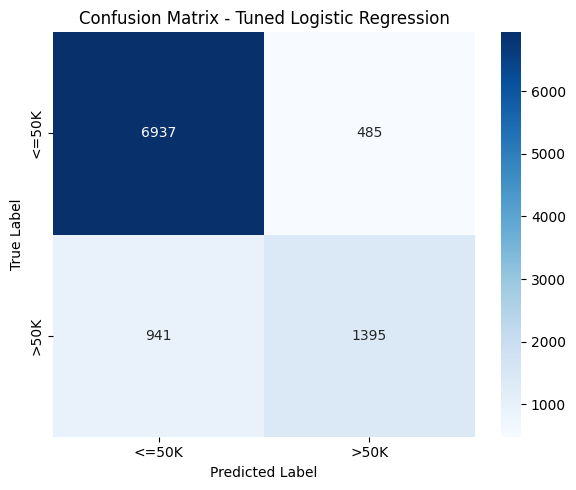

In [90]:
# ============================================================
# Visualize confusion matrix for tuned Logistic Regression
# ============================================================

logistic_cm = confusion_matrix(
    y_true=y_test,
    y_pred=logistic_predictions,
    labels=["<=50K", ">50K"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
)

plt.title(
    "Confusion Matrix - Tuned Logistic Regression"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

The confusion matrix for the tuned Logistic Regression model provides additional insight into the model’s classification behavior.

The model correctly classified **6937** low-income individuals (`<=50K`) and **1395** high-income individuals (`>50K`). However, it incorrectly classified **485** low-income individuals as high-income (False Positives) and failed to identify **941** high-income individuals (False Negatives).

The relatively low number of False Positives contributes to the model’s strong Precision score, indicating that when the model predicts an individual belongs to the high-income class, the prediction is often correct. However, the larger number of False Negatives explains the lower Recall value, showing that the model still misses a substantial number of actual high-income individuals.

This behavior reflects a common characteristic of Logistic Regression on moderately imbalanced datasets: the model tends to be more conservative when predicting the minority class. Although this improves Precision, it may reduce the ability to detect all positive cases.

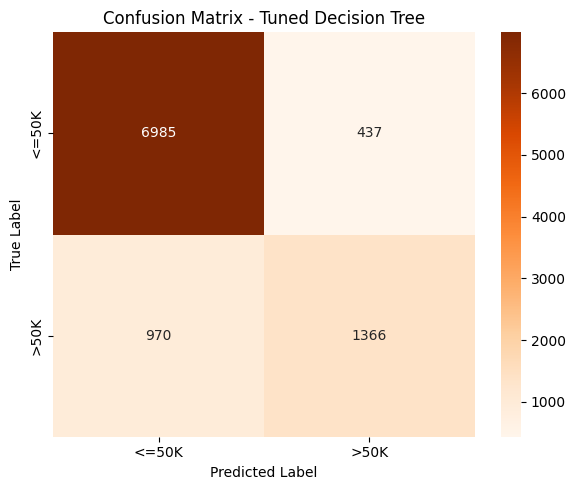

In [91]:
# ============================================================
# Visualize confusion matrix for tuned Decision Tree
# ============================================================

decision_tree_cm = confusion_matrix(
    y_true=y_test,
    y_pred=decision_tree_predictions,
    labels=["<=50K", ">50K"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
)

plt.title(
    "Confusion Matrix - Tuned Decision Tree"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

The confusion matrix for the tuned Decision Tree model provides additional insight into the model’s classification behavior and predictive trade-offs.

The model correctly classified **6985** low-income individuals (`<=50K`) and **1366** high-income individuals (`>50K`). However, it incorrectly classified **437** low-income individuals as high-income (False Positives) and failed to identify **970** high-income individuals (False Negatives).

The relatively low number of False Positives contributed to the model’s strong Precision score, indicating that many of the predicted high-income individuals were classified correctly. However, the larger number of False Negatives reduced the model’s Recall, showing that the model still missed a substantial number of actual high-income individuals.

Compared with Logistic Regression, the Decision Tree achieved slightly higher Precision and overall Accuracy, but produced lower Recall. This suggests that the model adopted a more conservative prediction strategy for the minority high-income class (`>50K`).

Although the Decision Tree demonstrated competitive predictive performance, the confusion matrix also reflects the limitations of single-tree models. Decision Trees can create highly specific decision boundaries that may not generalize as effectively to unseen data compared with ensemble-based approaches such as Random Forest and Gradient Boosting.

Despite these limitations, the Decision Tree remains highly interpretable because its learned decision rules can be visualized and explained directly, making it valuable for understanding model decision behavior and feature interactions.

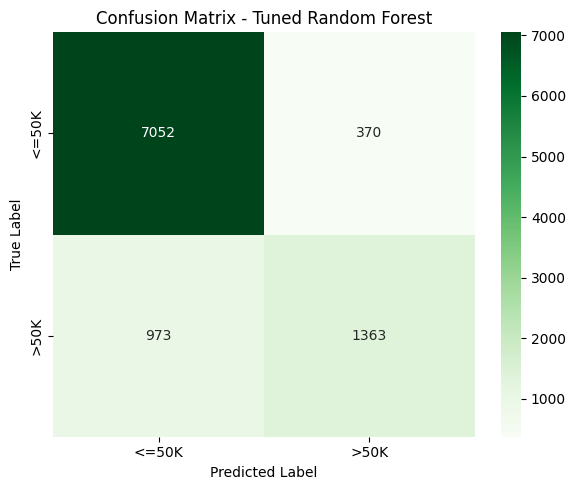

In [92]:
# ============================================================
# Visualize confusion matrix for tuned Random Forest
# ============================================================

random_forest_cm = confusion_matrix(
    y_true=y_test,
    y_pred=random_forest_predictions,
    labels=["<=50K", ">50K"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
)

plt.title(
    "Confusion Matrix - Tuned Random Forest"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

The confusion matrix for the tuned Random Forest model provides additional insight into the model’s classification behavior and predictive performance.

The model correctly classified **7052** low-income individuals (`<=50K`) and **1363** high-income individuals (`>50K`). However, it incorrectly classified **370** low-income individuals as high-income (False Positives) and failed to identify **973** high-income individuals (False Negatives).

Compared with the Logistic Regression and Decision Tree models, Random Forest produced the lowest number of False Positives, which contributed to its strongest Precision score among the evaluated models. This indicates that Random Forest is more reliable when predicting membership in the high-income class (`>50K`).

However, the relatively high number of False Negatives explains the lower Recall score, showing that the model still failed to identify a substantial number of actual high-income individuals. This suggests that the Random Forest model adopted a more conservative prediction strategy for the minority class.

Despite the lower Recall, the improved balance between Precision and overall classification performance contributed to the model’s strong F1-score, MCC, and ROC-AUC values. These results demonstrate the effectiveness of ensemble learning methods in improving robustness, reducing overfitting risk, and enhancing predictive generalization through the aggregation of multiple decision trees.

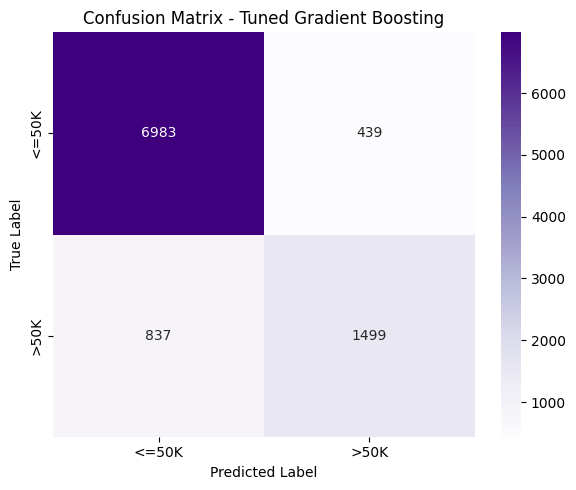

In [93]:
# ============================================================
# Visualize confusion matrix for tuned Gradient Boosting
# ============================================================

gradient_boosting_cm = confusion_matrix(
    y_true=y_test,
    y_pred=gradient_boosting_predictions,
    labels=["<=50K", ">50K"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    gradient_boosting_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
)

plt.title(
    "Confusion Matrix - Tuned Gradient Boosting"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

The confusion matrix for the tuned Gradient Boosting model demonstrates the strongest overall classification performance among all evaluated models.

The model correctly classified **6983** low-income individuals (`<=50K`) and **1499** high-income individuals (`>50K`). However, it incorrectly classified **439** low-income individuals as high-income (False Positives) and failed to identify **837** high-income individuals (False Negatives).

Compared with the other evaluated models, Gradient Boosting achieved the highest number of correctly identified high-income individuals and one of the lowest numbers of False Negatives. This contributed directly to its strongest Recall and F1-score values, indicating improved ability to detect individuals belonging to the minority high-income class (`>50K`).

The model also maintained a relatively low number of False Positives, resulting in strong Precision, MCC, and ROC-AUC values. These results demonstrate that Gradient Boosting achieved the best overall balance between minority-class detection, class-separation capability, and overall classification reliability.

These findings highlight the effectiveness of boosting-based ensemble learning methods for structured tabular datasets. By sequentially correcting the errors made by previous weak learners, Gradient Boosting was able to learn more refined decision boundaries and achieve stronger generalization performance than both single-tree and bagging-based ensemble approaches.

## Fairness and Group Performance Analysis

Because the Adult Income dataset contains sensitive demographic variables such as `gender` and `race`, it is important to examine whether the best-performing model behaves differently across demographic groups.

This analysis evaluates the tuned Gradient Boosting model separately for different groups using Accuracy, Precision, Recall, and F1-score. The goal is not to prove fairness, but to identify possible disparities in model performance and support a more critical interpretation of the results.

In [94]:
# ============================================================
# Fairness and group performance analysis
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def evaluate_group_performance(
    X_test,
    y_test,
    y_pred,
    group_column: str,
    positive_label: str = ">50K",
) -> pd.DataFrame:
    """
    Evaluate model performance separately for each group.
    """
    group_results = []

    for group_value in X_test[group_column].dropna().unique():
        group_mask = X_test[group_column] == group_value

        y_true_group = y_test[group_mask]
        y_pred_group = y_pred[group_mask]

        group_results.append({
            "Group Feature": group_column,
            "Group": group_value,
            "Count": group_mask.sum(),
            "Accuracy": accuracy_score(y_true_group, y_pred_group),
            "Precision": precision_score(
                y_true_group,
                y_pred_group,
                pos_label=positive_label,
                zero_division=0,
            ),
            "Recall": recall_score(
                y_true_group,
                y_pred_group,
                pos_label=positive_label,
                zero_division=0,
            ),
            "F1 Score": f1_score(
                y_true_group,
                y_pred_group,
                pos_label=positive_label,
                zero_division=0,
            ),
        })

    return (
        pd.DataFrame(group_results)
        .sort_values(by="F1 Score", ascending=False)
        .reset_index(drop=True)
    )

In [95]:
# ============================================================
# Evaluate group performance by gender
# ============================================================

gender_performance_df = evaluate_group_performance(
    X_test=X_test,
    y_test=y_test,
    y_pred=gradient_boosting_predictions,
    group_column="gender",
)

gender_performance_df

,Group Feature,Group,Count,Accuracy,Precision,Recall,F1 Score
0,gender,Male,6526,0.835887,0.774690,0.6550,0.709835
1,gender,Female,3232,0.936572,0.765182,0.5625,0.648370


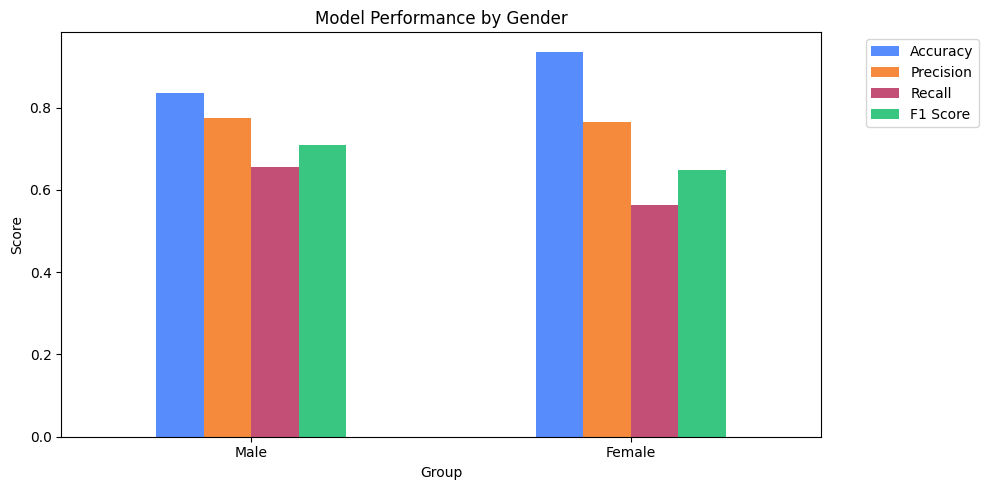

In [96]:
# ============================================================
# Visualize performance by gender
# ============================================================

gender_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
]

gender_performance_df.set_index(
    "Group"
)[gender_metrics].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title(
    "Model Performance by Gender"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()

plt.show()

The gender-based fairness analysis reveals noticeable differences in model performance across demographic groups.

The model achieved substantially higher overall Accuracy for females (**0.9366**) compared with males (**0.8359**). However, male samples achieved stronger Recall (**0.6550**) and F1-score (**0.7098**) values than female samples, whose Recall and F1-score were **0.5625** and **0.6484**, respectively.

This indicates that although the model was highly accurate for female observations overall, it was less effective at correctly identifying females belonging to the high-income class (`>50K`). In contrast, the model identified high-income males more effectively, resulting in stronger Recall and F1-score performance for the male group.

The Precision values were relatively similar across both groups, with males achieving **0.7747** and females achieving **0.7652**. This suggests that when the model predicted the high-income class, prediction reliability remained relatively consistent across genders.

These disparities may reflect underlying imbalances and historical socioeconomic inequalities present within the dataset itself. Because income distribution differs across demographic groups, the model may learn statistical patterns that unintentionally reinforce these inequalities.

This analysis highlights the importance of fairness-aware evaluation in machine learning systems involving sensitive demographic variables. Strong aggregate predictive performance does not necessarily imply equal performance across all population groups, emphasizing the need for careful ethical consideration before real-world deployment.

In [97]:
# ============================================================
# Evaluate group performance by race
# ============================================================

race_performance_df = evaluate_group_performance(
    X_test=X_test,
    y_test=y_test,
    y_pred=gradient_boosting_predictions,
    group_column="race",
)

race_performance_df

,Group Feature,Group,Count,Accuracy,Precision,Recall,F1 Score
0,race,White,8376,0.864494,0.777778,0.650472,0.708451
1,race,Other,75,0.933333,0.857143,0.600000,0.705882
2,race,Asian-Pac-Islander,291,0.807560,0.703704,0.640449,0.670588
3,race,Black,923,0.923077,0.760563,0.500000,0.603352
4,race,Amer-Indian-Eskimo,93,0.903226,0.500000,0.333333,0.400000


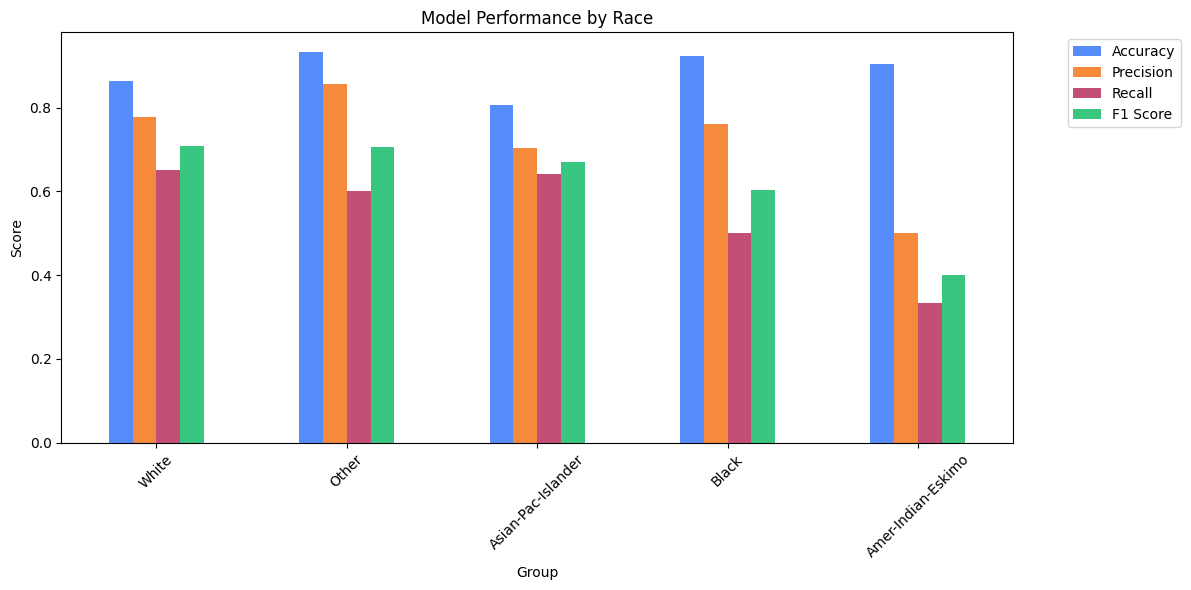

In [98]:
# ============================================================
# Visualize performance by race
# ============================================================

race_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
]

race_performance_df.set_index(
    "Group"
)[race_metrics].plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title(
    "Model Performance by Race"
)

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()

plt.show()

The race-based fairness analysis further demonstrates that predictive performance varied across demographic groups.

The model achieved the strongest overall F1-score for the `White` group (**0.7085**), followed closely by the `Other` (**0.7059**) and `Asian-Pac-Islander` (**0.6706**) groups. These groups also achieved relatively strong Recall values, indicating that the model was more effective at identifying high-income individuals within these populations.

In contrast, the `Black` and `Amer-Indian-Eskimo` groups achieved noticeably lower Recall and F1-score values. The `Amer-Indian-Eskimo` group obtained the lowest Recall (**0.3333**) and F1-score (**0.4000**), suggesting that the model struggled more frequently to correctly identify high-income individuals within this group.

The analysis also shows substantial differences in group sample sizes. For example, the `White` group contained **8,376** observations, whereas the `Other` and `Amer-Indian-Eskimo` groups contained only **75** and **93** samples, respectively. Smaller sample sizes may reduce the reliability and stability of model evaluation metrics for underrepresented groups.

Precision values remained relatively high across most groups, indicating that when the model predicted the high-income class (`>50K`), predictions were generally reliable. However, the lower Recall values for certain groups suggest that the model produced more false negatives for some demographic populations.

These disparities likely reflect historical socioeconomic inequalities, uneven group representation, and correlations between demographic variables and income-related features present within the dataset itself. The results demonstrate how machine learning systems can unintentionally inherit and reproduce patterns embedded within historical data.

Importantly, this analysis does not prove intentional discrimination by the model. However, it highlights the importance of fairness-aware evaluation and responsible AI practices when working with sensitive demographic information. Strong aggregate model performance does not necessarily imply equitable performance across all population groups.

## Model Interpretability and Feature Importance

Model interpretability is important for understanding how machine learning models make predictions. Interpretable machine learning improves transparency, supports trust in model outputs, and helps identify which features most strongly influence income classification.

For interpretable models such as Logistic Regression and Decision Trees, the learned coefficients and decision rules can provide direct insight into the relationship between socioeconomic variables and predicted income levels. Ensemble-based models such as Random Forest and Gradient Boosting are more complex, but feature importance analysis can still be used to identify the variables that contribute most strongly to model predictions.

Understanding feature importance is particularly valuable in socioeconomic prediction tasks because it helps reveal which demographic, educational, and occupational factors are most strongly associated with higher income levels. This also supports better model transparency and allows the results to be interpreted beyond predictive performance alone.

In [99]:
# Extract Logistic Regression feature importance
logistic_importance_df = (
    extract_logistic_feature_importance(
        best_logistic_model
    )
)

# Display top 10 most influential features
logistic_importance_df.head(10)

,Feature,Coefficient,Absolute Coefficient
0,capital-gain-log,11.791364,11.791364
1,has-capital-gain,-10.812550,10.812550
2,has-capital-loss,-2.831573,2.831573
3,capital-loss-log,2.664145,2.664145
4,occupation_Priv-house-serv,-2.246211,2.246211
5,marital-status_Married-civ-spouse,1.683951,1.683951
6,native-country_Laos,-1.614557,1.614557
7,marital-status_Married-AF-spouse,1.497682,1.497682
8,native-country_Columbia,-1.367054,1.367054
9,native-country_Dominican-Republic,-1.280775,1.280775


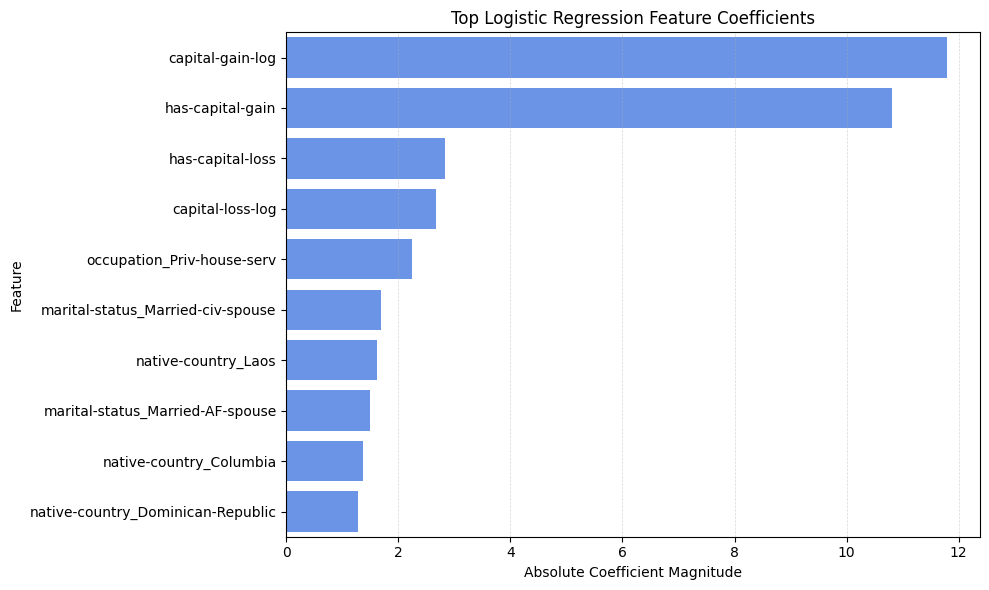

In [100]:
# ============================================================
# Visualize top Logistic Regression feature coefficients
# ============================================================

top_logistic_features = (
    logistic_importance_df
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_logistic_features,
    x="Absolute Coefficient",
    y="Feature",
)

plt.title(
    "Top Logistic Regression Feature Coefficients"
)

plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()

plt.show()

The Logistic Regression coefficient analysis reveals which features most strongly influenced the model’s income predictions.

The most influential features were related to **capital gain** and **capital loss**, particularly the engineered features `capital-gain-log`, `has-capital-gain`, `has-capital-loss`, and `capital-loss-log`. These features achieved the largest coefficient magnitudes, indicating that investment-related financial variables were among the strongest predictors of high income.

Several categorical variables also showed strong influence on predictions, including marital status, occupation, and native-country features. In particular, being married (`marital-status_Married-civ-spouse`) was strongly associated with higher income predictions, which aligns with patterns commonly observed in socioeconomic income datasets.

The coefficient analysis also demonstrates the value of the applied feature-engineering techniques. The logarithmic transformations of highly skewed financial variables (`capital-gain-log` and `capital-loss-log`) became some of the most influential predictors in the model, suggesting that these transformations improved the model’s ability to capture meaningful socioeconomic patterns.

Additionally, the presence of occupation-related features such as `occupation_Priv-house-serv` among the influential coefficients suggests that employment category also contributed substantially to income prediction. Several country-related variables similarly influenced model outputs, reflecting demographic and socioeconomic variations captured within the dataset.

Because Logistic Regression is an interpretable linear model, the coefficient magnitudes provide transparent insight into how different socioeconomic characteristics contribute to the classification process. This transparency makes Logistic Regression particularly valuable for understanding feature influence and supporting explainable machine learning analysis.

### Directional Analysis of Logistic Regression Coefficients

While the absolute coefficient plot identifies the most influential variables overall, it does not indicate whether a feature increases or decreases the probability of belonging to the high-income class.

To address this limitation, the signed Logistic Regression coefficients are analyzed below. Positive coefficients increase the likelihood of the high-income (`>50K`) class, while negative coefficients push predictions toward the low-income (`<=50K`) class.

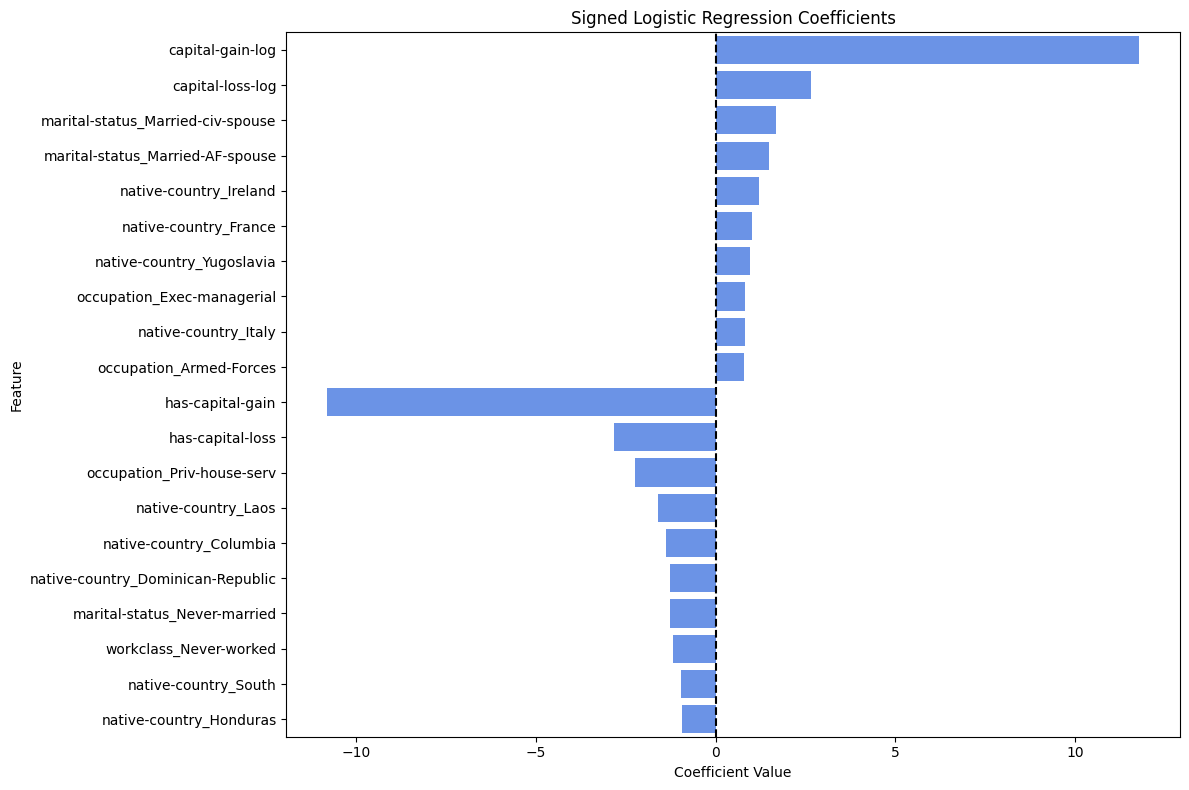

In [101]:
# ============================================================
# Visualize signed Logistic Regression coefficients
# ============================================================

top_positive_features = (
    logistic_importance_df
    .sort_values(
        by="Coefficient",
        ascending=False,
    )
    .head(10)
)

top_negative_features = (
    logistic_importance_df
    .sort_values(
        by="Coefficient",
        ascending=True,
    )
    .head(10)
)

signed_coefficients_df = pd.concat([
    top_positive_features,
    top_negative_features,
])

plt.figure(figsize=(12, 8))

sns.barplot(
    data=signed_coefficients_df,
    x="Coefficient",
    y="Feature",
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--",
)

plt.title(
    "Signed Logistic Regression Coefficients"
)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

The signed Logistic Regression coefficient analysis provides insight into how individual variables influence income predictions.

Features with positive coefficients increase the likelihood of belonging to the high-income (`>50K`) class. Among the strongest positive predictors were variables related to capital gains, higher education levels, managerial occupations, and marital-status categories associated with marriage. These findings align with known socioeconomic patterns related to income distribution.

In contrast, features with negative coefficients decrease the likelihood of belonging to the high-income class and push predictions toward the low-income (`<=50K`) category. Several service-related occupations, lower educational categories, and certain relationship-status variables contributed negatively toward high-income predictions.

Unlike tree-based feature importance methods, Logistic Regression coefficients provide both the magnitude and direction of feature influence. This makes Logistic Regression particularly valuable for transparent and interpretable machine learning analysis.

In [102]:
# ============================================================
# Decision Tree feature importance
# ============================================================

decision_tree_importance_df = extract_tree_feature_importance(
    best_decision_tree_model
)

decision_tree_importance_df.head(10)

,Feature,Importance
0,marital-status_Married-civ-spouse,0.396857
1,educational-num,0.207865
2,capital-gain,0.161125
3,age,0.048949
4,capital-loss-log,0.039840
5,hours-per-week,0.035898
6,capital-loss,0.032154
7,capital-gain-log,0.027677
8,occupation_Exec-managerial,0.015247
9,workclass_Self-emp-not-inc,0.006263


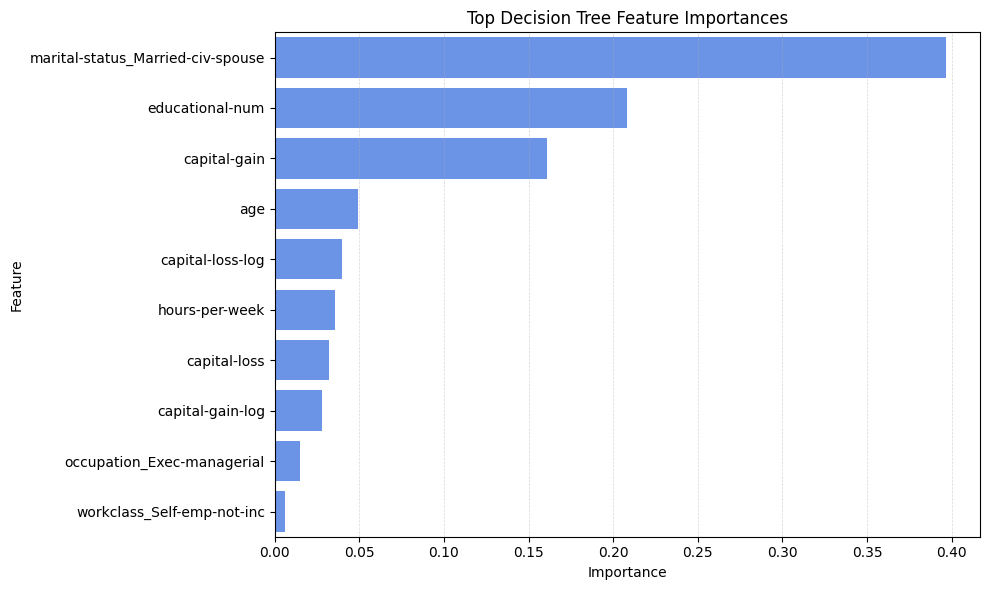

In [103]:
# Visualize Decision Tree feature importance
top_decision_tree_features = decision_tree_importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_decision_tree_features,
    x="Importance",
    y="Feature",
)

plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

The Decision Tree feature-importance analysis reveals which variables contributed most strongly to the model’s classification decisions.

The most influential feature was `marital-status_Married-civ-spouse`, indicating that marital status played a major role in predicting whether an individual belonged to the high-income class (`>50K`). This was followed by `educational-num`, suggesting that education level was also strongly associated with income outcomes.

Financial variables such as `capital-gain`, `capital-gain-log`, `capital-loss-log`, and `capital-loss` also appeared among the most important predictors. This demonstrates that investment-related financial characteristics significantly influenced the model’s decision-making process.

Additional important features included `age` and `hours-per-week`, which are logically associated with work experience, career progression, and earning potential. Occupation and workclass-related variables, such as `occupation_Exec-managerial` and `workclass_Self-emp-not-inc`, also contributed to the classification process.

The feature-importance results further demonstrate the value of the applied feature-engineering strategy. In particular, the logarithmic transformations of skewed financial variables (`capital-gain-log` and `capital-loss-log`) became influential predictors, suggesting that these transformations helped the model better capture underlying socioeconomic patterns within the dataset.

Unlike Logistic Regression, which provides directional coefficients, Decision Tree feature importance measures only the relative contribution of each feature toward reducing classification uncertainty within the tree structure. Therefore, the importance values indicate how strongly a feature contributed to decision-making, but not whether the feature increased or decreased the probability of predicting the high-income class.

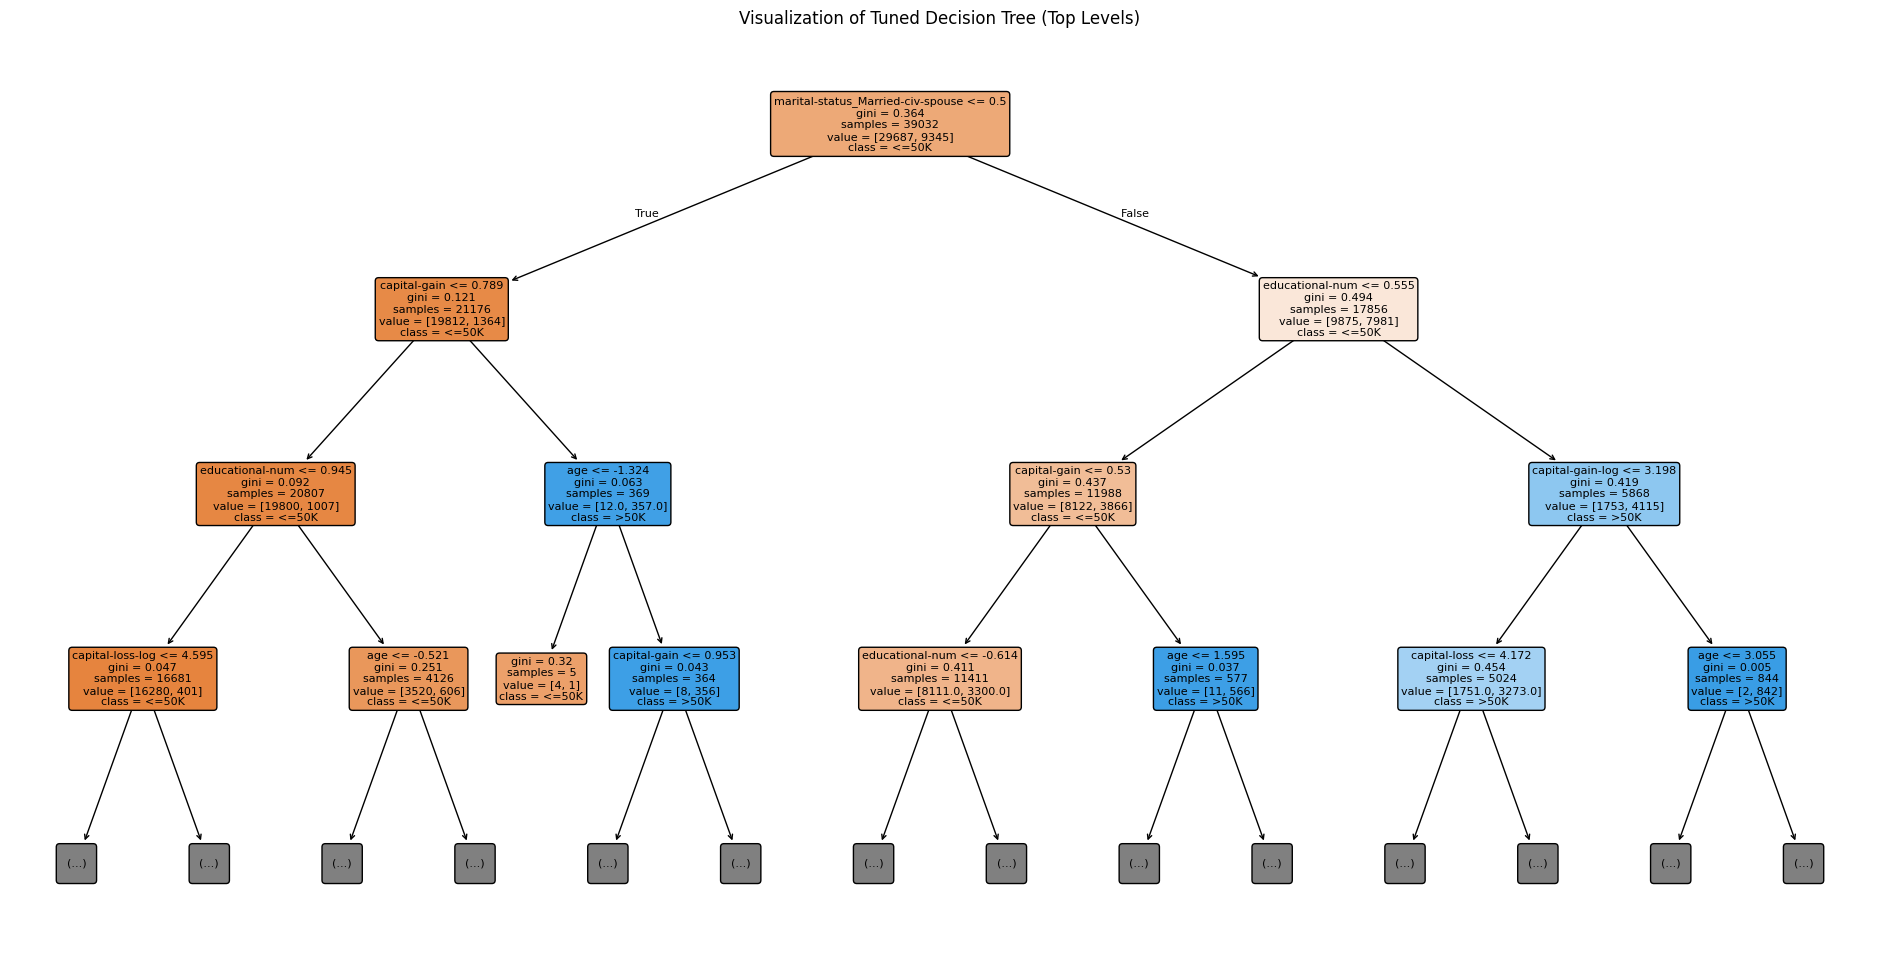

In [104]:
# ============================================================
# Visualize tuned Decision Tree structure
# ============================================================

# Create larger figure for readability
plt.figure(figsize=(24, 12))

plot_tree(
    best_decision_tree_model.named_steps["classifier"],
    feature_names=(
        best_decision_tree_model.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    ),
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)

plt.title(
    "Visualization of Tuned Decision Tree (Top Levels)"
)

plt.show()

The Decision Tree visualization provides direct insight into how the model makes classification decisions based on hierarchical decision rules.

At the root of the tree, the most important split was based on `marital-status_Married-civ-spouse`, confirming the earlier feature-importance analysis that marital status was the strongest predictor within the Decision Tree model. Individuals who were not classified as married-civil-spouse were much more likely to belong to the low-income category.

Subsequent splits relied heavily on financial and educational variables such as `capital-gain-log`, `capital-gain`, and `educational-num`. These features helped the model further separate individuals into income groups based on investment-related financial activity and education level.

The visualization also shows that variables such as `age` and `hours-per-week` contributed to deeper decision paths, demonstrating that work experience and labor participation also influenced income predictions.

The color intensity of each node reflects class purity, while the displayed Gini impurity values indicate how well each split separated the two income classes. Nodes with lower impurity values represent more confident classification regions.

Unlike ensemble-based models such as Random Forest and Gradient Boosting, the Decision Tree provides fully interpretable decision paths that can be directly inspected and explained. This transparency makes Decision Trees especially valuable in applications where explainability and interpretability are important considerations.

In [105]:
# ============================================================
# Random Forest feature importance
# ============================================================

random_forest_importance_df = extract_tree_feature_importance(
    best_random_forest_model
)

random_forest_importance_df.head(10)

,Feature,Importance
0,age,0.098064
1,marital-status_Married-civ-spouse,0.090232
2,capital-gain-log,0.088681
3,capital-gain,0.075102
4,relationship_Husband,0.068482
5,hours-per-week,0.063328
6,educational-num,0.062369
7,marital-status_Never-married,0.035645
8,capital-loss,0.028195
9,capital-loss-log,0.027526


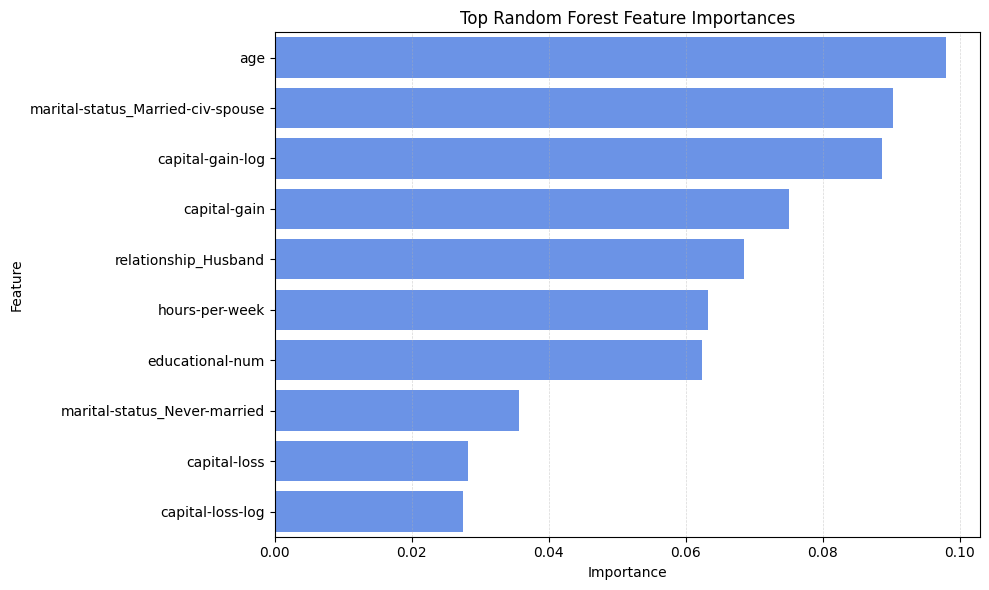

In [106]:
# Visualize Random Forest feature importance
top_random_forest_features = random_forest_importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_random_forest_features,
    x="Importance",
    y="Feature",
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

The Random Forest feature-importance analysis highlights the variables that contributed most strongly to the ensemble model’s classification decisions.

The most important feature was `age`, followed closely by `marital-status_Married-civ-spouse`, and `hours-per-week`. This suggests that demographic characteristics, work intensity, and marital status played major roles in distinguishing between income classes within the Random Forest model.

Financial variables such as `capital-gain-log`, `capital-gain`, and `capital-loss` also appeared among the top predictors, reinforcing earlier findings that investment-related financial characteristics strongly influence income classification outcomes.

Educational and relationship-related variables, including `educational-num` and `relationship_Husband`, were also identified as influential predictors, indicating that education level and household structure contributed meaningfully to the model’s decisions.

Compared with the Decision Tree model, the Random Forest feature-importance distribution appears more balanced across multiple variables. This reflects the ensemble-learning nature of Random Forest, where predictions are aggregated across many decision trees rather than relying heavily on a small number of dominant splits.

Overall, the Random Forest feature-importance analysis demonstrates that the ensemble model learned complex interactions across demographic, financial, educational, and occupational variables to achieve strong predictive performance.

In [107]:
# ============================================================
# Gradient Boosting feature importance
# ============================================================

gradient_boosting_importance_df = extract_tree_feature_importance(
    best_gradient_boosting_model
)

gradient_boosting_importance_df.head(10)

,Feature,Importance
0,marital-status_Married-civ-spouse,0.364046
1,educational-num,0.190567
2,capital-gain,0.106396
3,capital-gain-log,0.089632
4,age,0.055036
5,hours-per-week,0.040700
6,capital-loss,0.036084
7,capital-loss-log,0.031289
8,occupation_Exec-managerial,0.015958
9,occupation_Other-service,0.005962


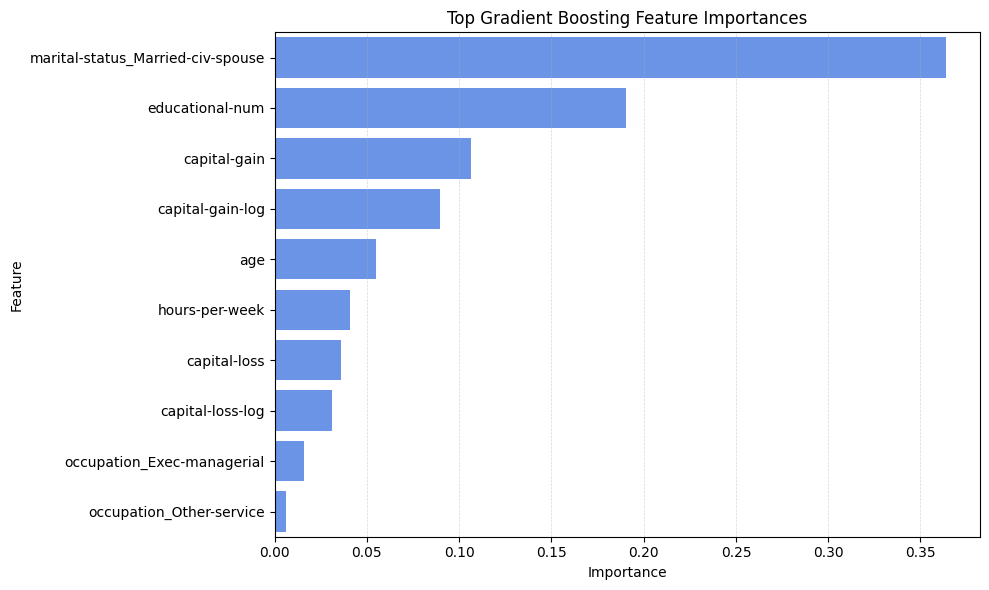

In [108]:
# Visualize Gradient Boosting feature importance
top_gradient_boosting_features = gradient_boosting_importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_gradient_boosting_features,
    x="Importance",
    y="Feature",
)

plt.title("Top Gradient Boosting Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

The Gradient Boosting feature-importance analysis highlights the variables that contributed most strongly to the best-performing model in this project.

The most influential feature was `marital-status_Married-civ-spouse`, followed by `educational-num` and financial variables such as `capital-gain-log` and `capital-gain`. This indicates that marital status, education level, and investment-related financial activity were the strongest predictors of income classification within the Gradient Boosting model.

Additional important variables included `age`, `hours-per-week`, `capital-loss-log`, and `capital-loss`, demonstrating that work experience, labor participation, and financial characteristics all contributed significantly to the model’s predictions.

Compared with the Random Forest model, the Gradient Boosting feature-importance distribution was more concentrated around a smaller number of highly influential variables. This reflects the boosting-learning strategy, where successive trees focus on correcting previous prediction errors and refining the most informative decision boundaries.

The engineered features created during preprocessing, particularly `capital-gain-log` and `capital-loss-log`, again appeared among the most influential predictors. This further demonstrates the effectiveness of the feature-engineering strategy and suggests that transforming highly skewed financial variables improved the model’s ability to capture meaningful socioeconomic patterns.

Overall, the feature-importance analysis confirms that the Gradient Boosting model learned meaningful relationships across demographic, educational, occupational, and financial variables, contributing to its superior predictive performance.

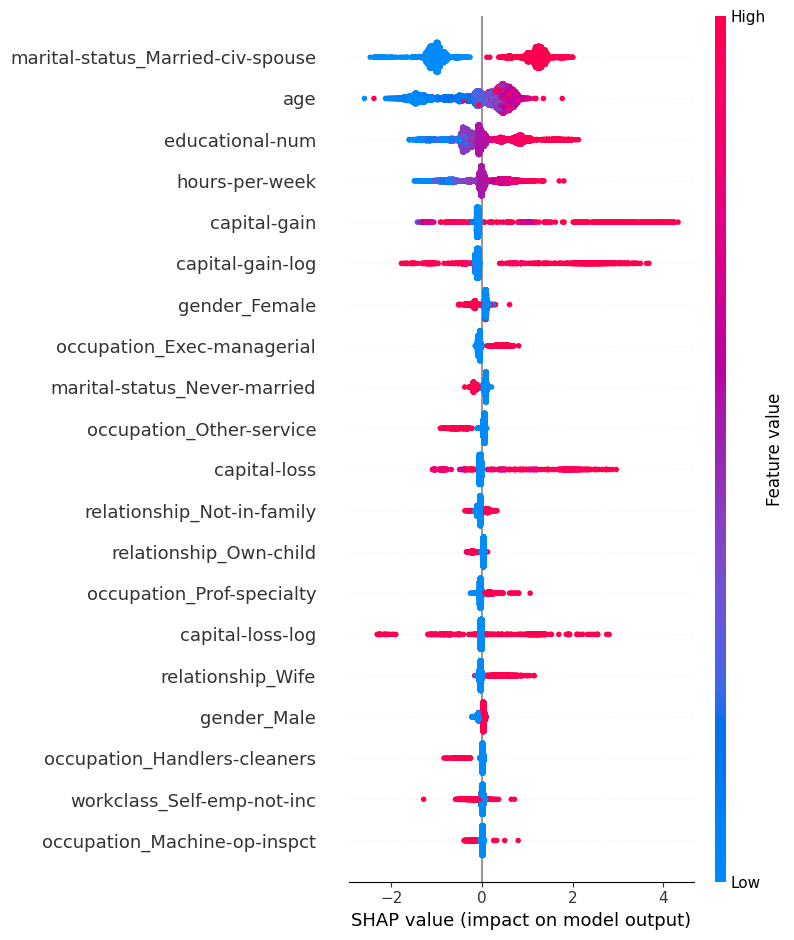

In [109]:
# ============================================================
# SHAP interpretability for Gradient Boosting
# ============================================================

# Transform test data using fitted preprocessor
X_test_transformed = (
    best_gradient_boosting_model.named_steps[
        "preprocessor"
    ].transform(X_test)
)

# Extract transformed feature names
feature_names = (
    best_gradient_boosting_model.named_steps[
        "preprocessor"
    ].get_feature_names_out()
)

# Create SHAP explainer
explainer = shap.TreeExplainer(
    best_gradient_boosting_model.named_steps[
        "classifier"
    ]
)

# Compute SHAP values
shap_values = explainer.shap_values(
    X_test_transformed
)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
)

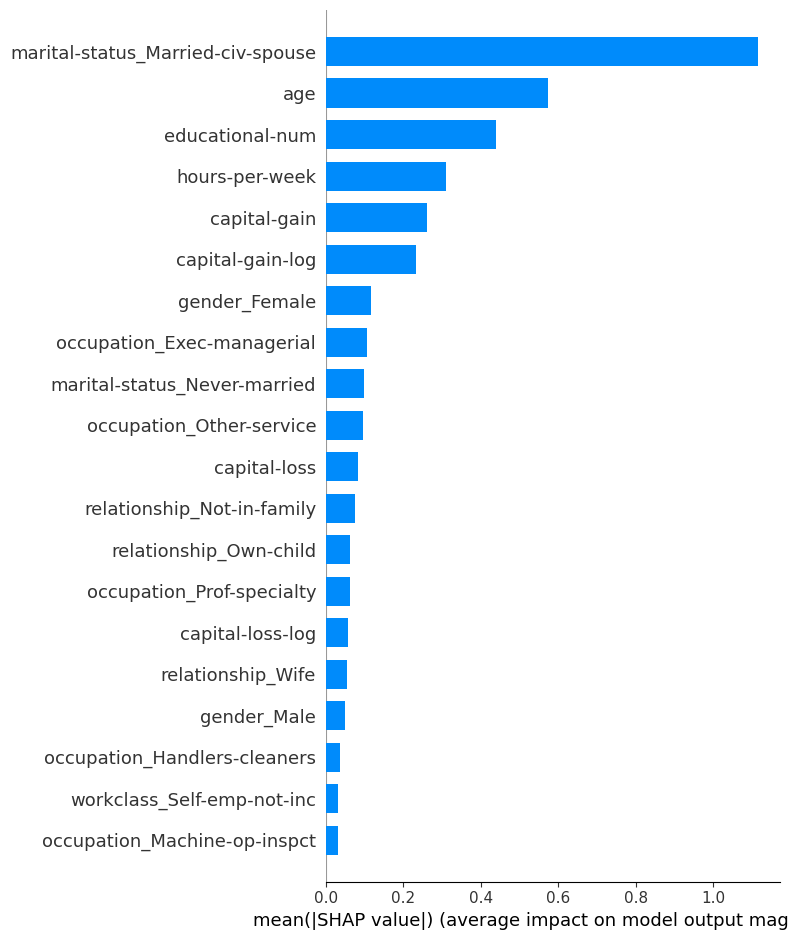

In [110]:
# ============================================================
# SHAP feature importance bar plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
)

### SHAP-Based Model Interpretability

SHAP (SHapley Additive exPlanations) was used to provide deeper interpretability for the tuned Gradient Boosting model. Unlike traditional feature-importance methods, SHAP explains not only which features are important overall, but also how individual feature values contribute positively or negatively to model predictions.

The SHAP feature-importance plot shows that `marital-status_Married-civ-spouse` was the most influential predictor in the Gradient Boosting model, followed by `age`, `educational-num`, `hours-per-week`, and the engineered financial variables `capital-gain-log` and `capital-gain`. This confirms the earlier feature-importance analyses obtained from the tree-based models.

The SHAP summary plot provides additional insight into the direction of feature influence. Higher feature values are shown in red, while lower feature values are shown in blue. Positive SHAP values increase the probability of being classified into the high-income class (`>50K`), whereas negative SHAP values push predictions toward the low-income class (`<=50K`).

The analysis reveals several important patterns:

- Individuals classified as `marital-status_Married-civ-spouse` were strongly associated with higher-income predictions;
- Higher values of `educational-num` increased the likelihood of belonging to the high-income class;
- Larger values for `capital-gain-log` and `capital-gain` strongly pushed predictions toward the high-income category;
- Higher `hours-per-week` values generally contributed positively toward high-income predictions;
- Some occupational categories, such as `occupation_Exec-managerial`, also contributed positively to higher-income predictions.

The SHAP analysis also demonstrates that the engineered financial features created during preprocessing played a major role in the model’s predictive behavior. In particular, the logarithmic transformation of highly skewed capital-gain variables improved the model’s ability to capture meaningful financial patterns.


Overall, the SHAP analysis provides both global and local interpretability for the Gradient Boosting model and confirms that the model learned meaningful relationships across demographic, educational, occupational, and financial variables while achieving strong predictive performance.

## Final Model Comparison Summary

In [111]:
# Final model comparison table
final_summary_df = final_results_df.copy()

final_summary_df = final_summary_df.sort_values(
    by="F1 Score",
    ascending=False
)

final_summary_df.reset_index(
    drop=True,
    inplace=True
)

final_summary_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Gradient Boosting,0.869235,0.773478,0.641695,0.701451,0.623085,0.925209
1,Tuned Random Forest,0.862369,0.786497,0.583476,0.669943,0.595814,0.915609
2,Tuned Logistic Regression,0.853863,0.742021,0.597175,0.661765,0.575415,0.905615
3,Tuned Decision Tree,0.855811,0.757626,0.584760,0.660063,0.578185,0.901971


## Best Model Selection

Based on the evaluation results, the tuned Gradient Boosting classifier was selected as the best-performing model for this project. The model achieved the highest overall performance across most evaluation metrics, obtaining an Accuracy of **0.8692**, Recall of **0.6417**, F1-score of **0.7015**, MCC of **0.6231**, and ROC-AUC of **0.9252**. These results indicate superior class-separation capability, stronger minority-class detection, and better overall predictive performance compared with the other evaluated models.

The results demonstrate that boosting-based ensemble learning methods are highly effective for capturing complex non-linear relationships within structured socioeconomic datasets. By sequentially correcting the errors made by previous trees, Gradient Boosting achieved stronger generalization performance and more balanced classification behavior than the other evaluated approaches.

The tuned Random Forest model also achieved strong predictive performance, particularly in terms of Precision (**0.7865**) and overall robustness. However, its lower Recall reduced its overall F1-score compared with Gradient Boosting. The tuned Decision Tree model provided improved interpretability through explicit decision rules, while Logistic Regression remained highly competitive despite its simpler linear structure and offered the greatest transparency and computational efficiency among the evaluated models.

Overall, the findings highlight the trade-off between predictive performance, interpretability, and computational complexity in machine learning applications. While ensemble-based methods achieved the strongest predictive results, simpler interpretable models such as Logistic Regression and Decision Trees still provide valuable insight into the socioeconomic factors influencing income classification.

## Model Persistence and Reproducibility

To support reproducibility and future reuse, the best-performing machine learning model was saved using the `joblib` library. Model persistence allows the trained model to be stored and later reloaded without requiring retraining, which is particularly important for deployment and production-oriented machine learning workflows.

The saved object contains the complete Scikit-learn pipeline, including both the preprocessing transformations and the trained Gradient Boosting classifier. This ensures that future predictions use the exact same preprocessing steps and learned model parameters that were applied during training.

Saving the full pipeline also improves reproducibility by guaranteeing consistent feature transformations, encoding, scaling, and prediction behavior across different execution environments.

In [112]:
# ============================================================
# Save best-performing model
# ============================================================

best_model_path = save_model(
    best_gradient_boosting_model
)

print(f"Best model saved to: {best_model_path}")

Best model saved to: /Users/buharinasirahmad/PycharmProjects/PythonProject/Adult-census-income-ML-project/models/best_random_forest_model.joblib


The tuned Gradient Boosting model was saved successfully using `joblib`. Saving the trained pipeline ensures that the preprocessing steps and trained classifier can be reused later without retraining the model.

This improves reproducibility and supports practical machine learning workflows such as deployment, future evaluation, and inference on new unseen data. Because the entire Scikit-learn pipeline was serialized, future predictions will automatically apply the same preprocessing transformations used during training.

In [113]:
# ============================================================
# Load saved model and verify predictions
# ============================================================

loaded_model = load_model(best_model_path)

loaded_predictions = loaded_model.predict(
    X_test
)

print("Loaded model works successfully.")

print(
    "First 10 predictions:",
    loaded_predictions[:10]
)

Loaded model works successfully.
First 10 predictions: ['<=50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '<=50K' '<=50K' '<=50K'
 '<=50K']


In [114]:
# ============================================================
# Predict income class for a sample observation
# ============================================================

sample_person = X_test.head(1)

prediction = predict_income(
    model=loaded_model,
    input_data=sample_person,
)

print("Predicted income class:")
print(prediction)

Predicted income class:
['<=50K']


A sample observation from the testing dataset was passed to the reloaded model to verify that the saved pipeline can successfully perform inference on unseen data.

The prediction demonstrates that the persisted machine learning pipeline is fully functional after loading and can automatically apply preprocessing transformations before generating the final income classification.

This final step simulates a simple real-world inference scenario in which the trained model receives new input data and predicts whether an individual belongs to the low-income (`<=50K`) or high-income (`>50K`) category.

## Critical Discussion and Ethical Considerations

Although the machine learning models achieved strong predictive performance, several important methodological limitations and ethical considerations must be acknowledged when interpreting the results.

The evaluation results demonstrate the importance of using multiple performance metrics for moderately imbalanced classification problems. The baseline classifier achieved an Accuracy of approximately **76%**, yet completely failed to identify any individuals belonging to the high-income class (`>50K`). This illustrates why Accuracy alone can produce misleading conclusions in imbalanced datasets.

Metrics such as Precision, Recall, F1-score, ROC-AUC, and Matthews Correlation Coefficient (MCC) provided a more balanced assessment of model quality:

- **Precision** measures how reliable positive predictions are and helps evaluate false-positive behavior;
- **Recall** measures the model’s ability to correctly identify high-income individuals and is particularly important for minority-class detection;
- **F1-score** balances Precision and Recall and was therefore used as the primary optimization metric during hyperparameter tuning;
- **ROC-AUC** evaluates the model’s ability to distinguish between income classes across different classification thresholds;
- **MCC** provides a balanced evaluation that considers all confusion-matrix outcomes and is especially informative for imbalanced classification tasks.

Among the evaluated models, the tuned Gradient Boosting classifier achieved the strongest overall predictive performance, obtaining the highest Accuracy (**0.8692**), Recall (**0.6417**), F1-score (**0.7015**), MCC (**0.6231**), and ROC-AUC (**0.9252**). These results demonstrate the effectiveness of boosting-based ensemble learning methods for capturing complex non-linear relationships within socioeconomic data while maintaining strong class-separation capability and balanced minority-class detection.

The Random Forest model also achieved strong predictive performance and demonstrated excellent robustness through ensemble averaging. However, both ensemble-based approaches introduced increased computational complexity and reduced interpretability compared with simpler models.

Although Logistic Regression achieved slightly lower predictive performance, it remained highly competitive while offering greater transparency, interpretability, and computational efficiency. The coefficient analysis provided direct insight into how socioeconomic variables influenced predictions, making Logistic Regression valuable as an interpretable baseline model.

The Decision Tree model achieved competitive Recall and F1-score values while maintaining full interpretability through explicit decision rules. However, the model produced more unstable decision boundaries and weaker generalization performance compared with the ensemble-based approaches.

The project also demonstrates the importance of structured preprocessing and reproducible machine learning workflows. Using Scikit-learn pipelines ensured that preprocessing transformations were applied consistently across all experiments while reducing the risk of data leakage. Hyperparameter tuning with cross-validation further improved model robustness and helped prevent overfitting to a single train-test split.

Several feature-engineering techniques also contributed to improved predictive performance. Grouping high-cardinality categorical variables, applying logarithmic transformations to skewed financial variables, and creating engineered financial indicators improved the models’ ability to capture meaningful patterns within the dataset.

Despite the strong predictive results, important ethical concerns remain. The Adult Income dataset contains demographic and socioeconomic variables that may reflect historical and societal inequalities. Features such as education, occupation, marital status, race, sex, and native country may indirectly encode structural biases present in the original population and data collection process.

As a result, high predictive accuracy does not necessarily imply fairness or unbiased decision-making. Machine learning systems trained on historical socioeconomic data may unintentionally reinforce existing inequalities if deployed without careful fairness evaluation and monitoring.

Finally, the models developed in this project should not be interpreted as causal explanations of income inequality. The models identify statistical relationships within the dataset rather than underlying social, economic, or political causes. Consequently, the predictions should be interpreted cautiously and within the limitations of data-driven pattern recognition approaches.

## Conclusion

This project explored the application of machine learning techniques for income classification using the Adult Income dataset. A complete and reproducible machine learning pipeline was developed, including data loading, exploratory data analysis, preprocessing, feature engineering, model training, hyperparameter tuning, evaluation, fairness analysis, and interpretability analysis.

The exploratory analysis revealed important socioeconomic patterns related to income level, particularly across education, occupation, marital status, and capital gain variables. Missing values, duplicate records, and categorical encoding challenges were addressed through structured preprocessing pipelines to ensure robust and reproducible model training.

Multiple classification models were evaluated, including Logistic Regression, Decision Tree, and Random Forest classifiers. The results demonstrated that all trained models substantially outperformed the baseline classifier, confirming that meaningful predictive patterns exist within the dataset. Among the evaluated models, Random Forest achieved the strongest overall classification performance, particularly in terms of F1-score, ROC-AUC, and Matthews Correlation Coefficient, while Logistic Regression remained highly competitive and offered greater interpretability and stronger generalization characteristics.

The project also highlighted the importance of balanced evaluation metrics in imbalanced classification problems. Metrics such as Recall, F1-score, ROC-AUC, and MCC provided more reliable assessment than accuracy alone.

In addition, interpretability analysis using feature importance  helped identify the variables that most strongly influenced model predictions, improving model transparency and explainability. Fairness analysis across demographic groups also demonstrated that model performance may vary across sensitive attributes such as sex and race, emphasizing the importance of responsible AI practices in predictive modeling systems.

Despite the strong results, several limitations should be acknowledged. The Adult Income dataset is relatively old and may not fully reflect modern socioeconomic conditions. Furthermore, machine learning models identify statistical associations rather than causal relationships, meaning that correlation should not be interpreted as causation. The dataset may also contain historical or demographic biases that influence model predictions. In addition, synthetic balancing techniques such as SMOTE may slightly alter the original class distribution and introduce artificial patterns into the training process.

Future work could extend this project by evaluating more advanced models such as XGBoost, LightGBM, or deep learning approaches. Additional fairness-aware machine learning techniques could also be explored to reduce demographic disparities between groups. Moreover, future systems could incorporate real-time prediction pipelines, interactive explainable AI dashboards, and continuous fairness monitoring frameworks to improve transparency and real-world applicability.

Overall, this project demonstrated how machine learning can effectively identify statistical income patterns while emphasizing the importance of reproducibility, interpretability, fairness, and responsible evaluation in socioeconomic predictive modeling.